---

# Data Science Competition JOINTS x INSPIRE UGM 2026 (v7)

*Memprediksi penjualan tiket harian D4 sampai D10 per pasangan film dan klaster bioskop dari tiga hari pertama, dengan model hurdle yang memisahkan keputusan bioskop mencopot film dari jumlah penonton, dikoreksi untuk kebijakan pencopotan periode uji yang terukur dari data berlabel periode uji.*

---

## [Nama Tim]

- [Nama Anggota 1] (Ketua)
- [Nama Anggota 2]
- [Nama Anggota 3]

---

## Table of Contents

1. [**Introduction**](#1)
2. [**Initialization**](#2)
3. [**Data Acquisition & Audit**](#3)
4. [**Exploratory Data Analysis**](#4)
5. [**Data Cleaning**](#5)
6. [**Preprocessing**](#6)
7. [**Feature Engineering**](#7)
8. [**Modeling**](#8)
9. [**Evaluation**](#9)
10. [**Inference & Submission**](#10)


---

# Introduction <a name="1"></a>

---

## Overview

*Operator bioskop harus menentukan alokasi layar ketika film baru hanya memiliki tiga hari riwayat penjualan. Data latih mencakup April sampai September 2025, sedangkan film uji dirilis Oktober 2025 sampai Maret 2026: musim sepi, libur Natal, Ramadan, dan Lebaran.*

*Versi sebelumnya memiliki MASE validasi yang dibobot ke komposisi uji (TW-MASE) 0,377 sampai 0,388 dengan peringkat yang sama seperti leaderboard, tetapi dengan offset tetap sekitar 0,07. Offset yang sama pada model yang berbeda menandakan kesalahan sistematis yang diwarisi dari data latih. v4 menemukan salah satu sumbernya (di periode uji bioskop jauh lebih jarang mencopot film pada tingkat penonton yang sama) dan turun ke 0,4481. v5 menambah dua hal: fitur kompetisi per klaster pada klasifier pencopotan, dan prediksi minggu Lebaran yang diturunkan dari total klaster Lebaran 2025 di data latih, dan turun ke 0,4087. Dengan itu, TW-MASE di dunia dengan separuh pergeseran pencopotan (v5: 0,4066) praktis sama dengan leaderboard, sehingga metrik ini menjadi metrik keputusan. v6 memakai TabPFN-3.5 dan mencapai 0,4012. v7 menambah TabPFN-3.5 yang di-fine-tune pada seluruh sampel latih (satu model untuk semua horizon, loss CRPS) sebagai komponen ketiga; bobot ketiga komponen dipilih dengan TW-MASE di dunia tersebut.*

## Aim

*Memprediksi `total_ticket` D4 sampai D10 untuk 72.611 baris uji dengan MASE sekecil mungkin pada private leaderboard, memakai metrik validasi yang terbukti sejalan dengan leaderboard.*

## Metric

***Mean Absolute Scaled Error (MASE)** membagi galat absolut setiap baris dengan skala pasangan, yaitu rata-rata D1 sampai D3 yang dibatasi minimal 1. MASE setara MAE pada rasio $r = y / s_p$, sehingga prediksi optimal adalah median bersyarat. Karena MASE adalah rata-rata biasa per baris, komposisi baris uji (misalnya porsi pasangan kecil) langsung menentukan skor.*

$$s_p = \max\left(\frac{1}{3}\sum_{d=1}^{3} y_{p,d},\ 1\right) \qquad \text{MASE} = \frac{1}{N}\sum_{i=1}^{N}\frac{|y_i - \hat{y}_i|}{s_{p(i)}}$$

## Dataset

*Data bersumber dari Kaggle Competition Data Science JOINTS x INSPIRE UGM 2026.*

*`train.csv` berisi 138.959 transaksi harian (1 April sampai 30 September 2025). `test_history.csv` berisi 32.323 transaksi D1 sampai D3 dari 163 judul uji, dan `test.csv` berisi 72.611 baris target (10.373 pasangan x 7 hari). Hari tanpa transaksi tidak tercatat dan bernilai nol.*

*Data digunakan untuk merekonstruksi sampel latih dengan aturan panitia, lalu memprediksi D4 sampai D10.*

**Attributes**

1.  `date_show`       : Tanggal penayangan
2.  `cinema_ids`      : ID anonim klaster bioskop
3.  `city_name`       : Kota lokasi klaster
4.  `movie_title`     : Judul film, termasuk penanda format (3D, IMAX 2D, IMAX 3D)
5.  `occupation_rate` : Persentase kursi terisi (0 sampai 100)
6.  `total_show`      : Jumlah pertunjukan

**Target**
 `total_ticket`       : Jumlah tiket terjual per pasangan per tanggal (0 bila tidak ada transaksi)

## Approach: Hurdle + L1 dengan Koreksi Kebijakan Pencopotan

*Temuan utama v3: galat per ukuran pasangan stabil antara periode latih dan periode uji, tetapi data uji memuat empat kali lebih banyak pasangan kecil (skala di bawah 20) yang galatnya paling besar. MASE validasi biasa karena itu terlalu optimistis. Seluruh keputusan di notebook ini diambil dengan **TW-MASE**, yaitu galat out-of-fold yang dibobot ke komposisi skala data uji.*

*Target $r = y / (s_p c_{mult})$ adalah campuran: nol bila bioskop mencopot film, positif bila tidak. Prediksi optimal MASE adalah median campuran: $0$ bila $p_0 \ge 0{,}5$, selain itu kuantil ke-$(0{,}5 - p_0)/(1 - p_0)$ dari bagian positif. Model hurdle LightGBM (klasifier $p_0$ dan 19 regresi kuantil) dan TabPFN v2 (kuantil prediktif, revisi Juni 2025) memakai rumus ini. Di periode uji, $p_0$ digeser $\text{logit}\,p_0' = \text{logit}\,p_0 + \lambda a$, dengan $a$ diukur dari data berlabel periode uji dan $\lambda = 0{,}5$ dipilih dengan minimax regret dari tiga sumber bukti. Model L1 ikut di-blend sebagai lindung nilai karena lebih tahan pada pasangan yang ternyata dicopot.*

```
train.csv -> D1 rilis resmi (segmen kontinu) -> simulasi aturan panitia -> + film rilis terbatas (latih saja)
                                                   |
test_history.csv ---------------------------------+--> build fitur (pasangan, film, kalender, jadwal, klaster)
                                                   |
      LightGBM L1  +  LightGBM hurdle (p0 + kuantil)  +  TabPFN v2 per horizon (kuantil)
                                                   |  p0 digeser lambda x a (a dari proxy periode uji)
                  y_hat = r_hat x c_mult x s_p, bobot blend dipilih dengan TW-MASE -> submission.csv
```

*Validasi: 5 fold dikelompokkan per judul dasar film (versi 2D, 3D, IMAX satu film di fold yang sama).*

---

# Initialization <a name="2"></a>

---

## Environment Setup

Notebook dirancang untuk Kaggle GPU T4 x2 dengan internet aktif (unduh bobot TabPFN dari Hugging Face). TabPFN memakai GPU pertama; LightGBM (L1, klasifier, dan 19 regresi kuantil) berjalan di CPU dengan `deterministic=True`. Recorded runtime v3 di T4: TabPFN OOF 18 menit dan fit akhir 21 menit; v4 menambah sekitar 15 sampai 25 menit untuk hurdle LightGBM.

In [1]:
!nvidia-smi

Sat Oct  3 09:00:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.178.04             Driver Version: 580.178.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

The following cell installs all libraries used in this notebook.

In [2]:
%pip install -q lightgbm==4.6.0 tabpfn==9.0.0 huggingface_hub==0.34.4 scikit-learn==1.6.1 pandas==2.2.3 scipy==1.15.2 matplotlib==3.10.0 seaborn==0.13.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 827.5/827.5 kB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.5/561.5 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 104.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 595.9/595.9 kB 26.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have p

## Import Libraries

In [3]:
import os
import random
import time
import pickle
import itertools
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import torch
from IPython.display import display
from huggingface_hub import hf_hub_download
from scipy.stats import ks_2samp
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GroupKFold, StratifiedGroupKFold
from tabpfn import TabPFNRegressor
from tabpfn.constants import ModelVersion
from tabpfn.finetuning import FinetunedTabPFNRegressor
try:
    from kaggle_secrets import UserSecretsClient
except ImportError:
    UserSecretsClient = None

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
PAL = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
sns.set_theme(style='whitegrid', palette=PAL, rc={'axes.spines.top': False, 'axes.spines.right': False})

## Seed Everything

In [4]:
def seed_everything(seed: int = 2026):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(2026)

## Settings

Seluruh path, konstanta hasil EDA, hyperparameter, dan flag dipusatkan di sini. `HURDLE_W` adalah bobot hurdle dalam komponen LightGBM dan `LAMBDA` porsi pergeseran kebijakan pencopotan yang diterapkan; keduanya dipilih dengan analisis keputusan di Bagian 8. `LEB_RHO` adalah porsi total pasar minggu Lebaran 2025 yang diasumsikan dicapai film Lebaran 2026 (Bagian 10). Tidak ada nilai yang disetel pada leaderboard.

In [5]:
class Settings:
    SEED       = 2026
    _ON_KAGGLE = Path('/kaggle/input').exists()

    DATA_DIR   = (
        next(Path('/kaggle/input').rglob('train.csv')).parent
        if _ON_KAGGLE else Path('../data')
    )
    OUTPUT_DIR = Path('/kaggle/working') if _ON_KAGGLE else Path('../outputs/v7')
    FIG_DIR    = OUTPUT_DIR / 'figures'

    TRAIN_END  = pd.Timestamp('2025-09-30')
    OUTAGE     = pd.to_datetime(['2025-06-07', '2025-06-09', '2025-06-10', '2025-06-13', '2025-06-16'])
    D1_FRAC    = 0.5
    MIN_NC     = 25
    USE_LIMITED = True

    DOW_PROF   = np.array([0.811, 0.789, 0.811, 0.783, 0.848, 1.290, 1.282])
    HOL_LEVEL  = 1.29
    SCHOOL_WD  = 1.15
    QS         = np.round(np.arange(0.05, 1.0, 0.05), 2)
    TAB_QS     = np.round(np.arange(0.02, 1.0, 0.02), 2)
    ZERO_EPS   = 0.02
    HURDLE_W   = 0.75
    LAMBDA     = 0.5
    LEB_RHO    = 0.5
    LEB_DAY1   = 0.75
    TW_BINS    = [0, 5, 20, 50, 100, 200, 500, 1e9]

    N_FOLDS    = 5
    SEEDS      = [2026, 2027, 2028, 2029, 2030]
    LGB_PARAMS = dict(objective='l1', learning_rate=0.03, num_leaves=63, min_child_samples=100,
                      feature_fraction=0.7, bagging_fraction=0.8, bagging_freq=1, lambda_l2=1.0,
                      n_estimators=800, deterministic=True, force_row_wise=True, n_jobs=4, verbose=-1)

    USE_TABPFN   = True
    TABPFN_REPO  = 'Prior-Labs/tabpfn_3_5'
    TABPFN_FILE  = 'tabpfn-v3.5-20260909.safetensors'
    TABPFN_REV   = '06bf2ba35c80a92a3b9abb436b99cf49e7a0365e'
    KAPPA        = 0.5
    TABPFN_EST   = 8
    USE_FT       = True
    FT_TIME      = 600
    FT_EPOCHS    = 30
    FT_LR        = 1e-5
    FT_CTX       = 10000
    FT_INF_CTX   = 20000
    DEVICE       = 'cuda' if torch.cuda.is_available() else 'cpu'

CFG = Settings()
CFG.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CFG.FIG_DIR.mkdir(parents=True, exist_ok=True)
print(CFG.DATA_DIR, CFG.DEVICE)

/kaggle/input/competitions/datajointsxinspire cuda


## Load Dataset

Semua berkas resmi dibaca dengan kolom tanggal langsung di-parse. Tidak ada visualisasi di sini.

In [6]:
read = lambda f, **k: pd.read_csv(CFG.DATA_DIR / f, **k)
train   = read('train.csv', parse_dates=['date_show'])
hist    = read('test_history.csv', parse_dates=['date_show'])
test    = read('test.csv', parse_dates=['date_show'])
sub     = read('sample_submission.csv')
movies  = read('movies.csv')
hol     = read('holidays.csv', parse_dates=['date'])
price   = read('ticket_prices.csv')
KEY     = ['movie_title', 'cinema_ids']

for n, x in [('train', train), ('test_history', hist), ('test', test), ('movies', movies),
             ('holidays', hol), ('ticket_prices', price)]:
    print(f'{n:14s} {x.shape}')

train          (138959, 7)
test_history   (32323, 7)
test           (72611, 5)
movies         (397, 7)
holidays       (366, 4)
ticket_prices  (207, 3)


---

# Data Acquisition & Audit <a name="3"></a>

---

Integritas data diperiksa sebelum analisis: rentang tanggal, nilai hilang, duplikat kunci, konsistensi klaster ke kota, dan irisan film serta klaster antara data latih dan data uji.

In [7]:
rows = []
for n, x in [('train', train), ('test_history', hist), ('test', test)]:
    rows.append(dict(file=n, rows=len(x), start=x.date_show.min().date(), end=x.date_show.max().date(),
                     films=x.movie_title.nunique(), cinemas=x.cinema_ids.nunique(), n_missing=int(x.isna().sum().sum())))
display(pd.DataFrame(rows))
for n, x in [('train', train), ('test_history', hist)]:
    print(f"{n}: duplicate (date, cinema, film) = {x.duplicated(['date_show'] + KEY).sum()}, zero-ticket rows = {(x.total_ticket == 0).sum()}")
print('clusters mapped to >1 city:', (pd.concat([train, hist]).groupby('cinema_ids').city_name.nunique() > 1).sum())
print('test ids aligned with sample_submission:', (sub.id.values == test.id.values).all())
print('test films also in train (previews):', len(set(test.movie_title) & set(train.movie_title)))
print('test clusters unseen in train:', len(set(test.cinema_ids) - set(train.cinema_ids)))

,file,rows,start,end,films,cinemas,n_missing
0,train,138959,2025-04-01,2025-09-30,237,117,0
1,test_history,32323,2025-10-01,2026-03-20,163,121,0
2,test,72611,2025-10-04,2026-03-27,160,121,0


train: duplicate (date, cinema, film) = 0, zero-ticket rows = 0
test_history: duplicate (date, cinema, film) = 0, zero-ticket rows = 0
clusters mapped to >1 city: 0
test ids aligned with sample_submission: True
test films also in train (previews): 10
test clusters unseen in train: 4


#### Insights

> Tidak ada nilai hilang, duplikat kunci, maupun baris bertiket nol: hari tanpa transaksi memang tidak tercatat, sehingga target harus diisi nol secara eksplisit. Sepuluh film uji muncul di train hanya sebagai pratinjau di beberapa klaster, dan empat klaster uji tidak pernah muncul di train.

---

# Exploratory Data Analysis <a name="4"></a>

---

EDA menjawab tiga pertanyaan yang langsung mengubah pipeline: bagaimana panitia membentuk data uji, periode kalender apa yang tidak pernah dilihat data latih, dan apakah level pasar periode uji berbeda.

## Aturan Seleksi Pasangan dan Filter Rilis Luas

`test_history.csv` memuat 11.823 pasangan, tetapi `test.csv` hanya 10.373. Pasangan dikelompokkan menurut hari terakhir yang masih bertransaksi, lalu cakupan klaster D1 film uji dibandingkan dengan judul di `movies.csv` yang tidak dipakai.

In [8]:
base_title = lambda t: t.str.replace(r'\s*\((IMAX 2D|IMAX 3D|3D)\)\s*$', '', regex=True).str.strip()
fmt = lambda t: t.str.extract(r'\((IMAX 2D|IMAX 3D|3D)\)\s*$')[0].fillna('2D')

d1_test = hist.groupby('movie_title').date_show.min()
h = hist.join(d1_test.rename('d1'), on='movie_title')
h['d'] = (h.date_show - h.d1).dt.days + 1
ph = h.groupby(KEY).d.max().rename('last_day').reset_index()
ph = ph.merge(test[KEY].drop_duplicates().assign(in_test=1), how='left').fillna({'in_test': 0})
display(pd.crosstab(ph.last_day, ph.in_test, margins=True))
nc1 = h[h.d == 1].groupby('movie_title').cinema_ids.nunique()
print('smallest D1 coverage of 2D test films:', nc1[fmt(pd.Series(nc1.index, index=nc1.index)) == '2D'].nsmallest(4).to_dict())
known = set(base_title(pd.Series(train.movie_title.unique()))) | set(base_title(pd.Series(hist.movie_title.unique())))
print('titles in movies.csv used nowhere:', len(set(movies.original_title) - known))
print('D1 weekday of test films:', d1_test.dt.day_name().value_counts().to_dict())

in_test,0.0,1.0,All
last_day,,,
1,514,0,514
2,936,0,936
3,0,10373,10373
All,1450,10373,11823


smallest D1 coverage of 2D test films: {'EPIC: ELVIS PRESLEY IN CONCERT': 28, '5 CENTIMETERS PER SECOND (ANIMATION)': 30, 'ONCE WE WERE US': 30, 'SETANNYA CUAN': 33}
titles in movies.csv used nowhere: 56
D1 weekday of test films: {'Wednesday': 67, 'Thursday': 65, 'Friday': 24, 'Saturday': 5, 'Tuesday': 2}


#### Insights

> Pasangan masuk data uji **jika dan hanya jika** bertransaksi pada D3. Film 2D terkecil di data uji dibuka di 28 klaster, sedangkan 56 judul lain (Bollywood rilis terbatas, konser, nobar) tidak dipakai: data uji hanya berisi rilis luas. D1 hampir selalu Rabu atau Kamis, yaitu tanggal rilis resmi.

## Efek Kalender dan Periode yang Tidak Ada di Data Latih

Efek kalender diisolasi dengan membagi penjualan setiap pasangan-hari dengan rata-rata bergerak 7 hari terpusat milik pasangan itu sendiri, sehingga umur film dan ukuran klaster terhapus.

weekday multiplier: {'Mon': 0.814, 'Tue': 0.794, 'Wed': 0.811, 'Thu': 0.783, 'Fri': 0.853, 'Sat': 1.32, 'Sun': 1.282}


,name,dow,excess
date_show,,,
2025-04-18,Wafat Yesus Kristus,4,1.54
2025-04-20,Kebangkitan Yesus Kristus (Paskah),6,0.88
2025-05-01,Hari Buruh Internasional,3,1.85
2025-05-12,Hari Raya Waisak 2569 BE,0,1.88
2025-05-29,Kenaikan Yesus Kristus,3,1.98
2025-06-01,Hari Lahir Pancasila,6,0.35
2025-06-06,Idul Adha 1446 H,4,3.08
2025-06-27,1 Muharam Tahun Baru Islam 1447 H,4,1.48
2025-08-17,Proklamasi Kemerdekaan Republik Indonesia,6,1.11


xmas     test rows   5235 (7.2%), films 15
ramadan  test rows  12408 (17.1%), films 37
lebaran  test rows   4417 (6.1%), films 7


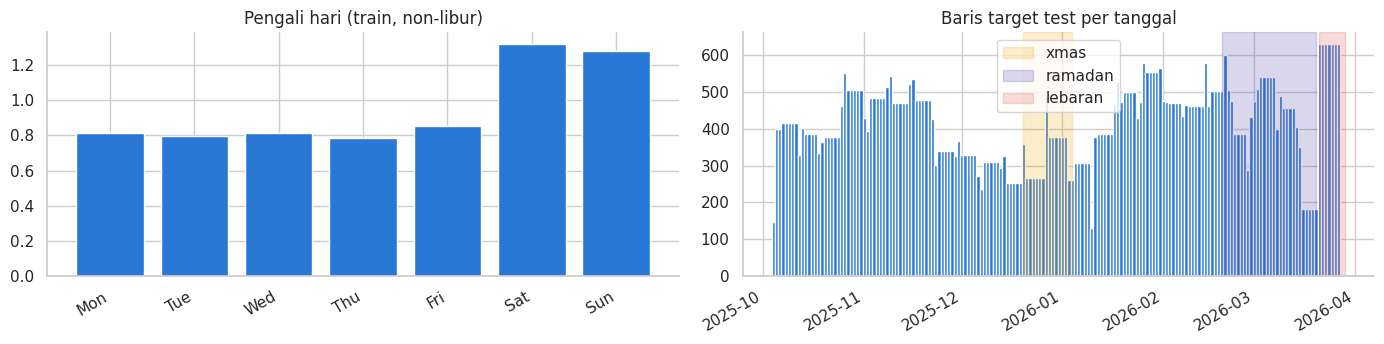

In [9]:
DOW = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
x = train.set_index('date_show').groupby(KEY).total_ticket.apply(lambda s: s.asfreq('D', fill_value=0)).reset_index()
x['m7'] = x.groupby(KEY).total_ticket.transform(lambda s: s.rolling(7, center=True).mean())
x = x[(x.m7 >= 20) & ~x.date_show.isin(CFG.OUTAGE)].merge(hol, left_on='date_show', right_on='date', how='left')
x['mult'] = x.total_ticket / x.m7
day = x.groupby('date_show').agg(mult=('mult', 'median'), hol=('holiday_tipe', 'first'), name=('holiday_name', 'first'))
day['dow'] = day.index.dayofweek
prof = day[day.hol == 'normal'].groupby('dow').mult.median()
day['excess'] = day.mult / day.dow.map(prof)
print('weekday multiplier:', dict(zip(DOW, prof.round(3))))
display(day[day.hol == 'holiday'][['name', 'dow', 'excess']].round(2))

SEGMENTS = {'xmas': ('2025-12-20', '2026-01-04'), 'ramadan': ('2026-02-19', '2026-03-20'), 'lebaran': ('2026-03-21', '2026-03-29')}
for n, (a, b) in SEGMENTS.items():
    m = test.date_show.between(a, b)
    print(f'{n:8s} test rows {m.sum():6d} ({m.mean():.1%}), films {test[m].movie_title.nunique()}')

fig, ax = plt.subplots(1, 2, figsize=(14, 3.6))
ax[0].bar(DOW, prof.values, color=PAL[0]); ax[0].set(title='Pengali hari (train, non-libur)')
cnt = test.groupby('date_show').size()
ax[1].bar(cnt.index, cnt.values, width=1, color=PAL[0])
for (n, (a, b)), c in zip(SEGMENTS.items(), [PAL[3], PAL[6], PAL[7]]):
    ax[1].axvspan(pd.Timestamp(a), pd.Timestamp(b), color=c, alpha=.2, label=n)
ax[1].set(title='Baris target test per tanggal'); ax[1].legend()
fig.autofmt_xdate(); plt.tight_layout(); plt.savefig(CFG.FIG_DIR / 'calendar.png'); plt.show()

#### Insights

> Sabtu dan Minggu sekitar 1,6 kali hari kerja, libur di hari kerja setara akhir pekan, libur di akhir pekan hampir tidak menambah. Sekitar 30% baris uji berada di periode yang tidak pernah ada di train: Ramadan (17,1%), libur Natal dan Tahun Baru (7,2%), dan Lebaran (6,1%). Efek kalender karena itu dimasukkan secara struktural sebagai pengali target, bukan dipelajari pohon keputusan yang tidak bisa ekstrapolasi.

## Level Pasar dan Ukuran Pasangan

Okupansi median per bulan dan distribusi skala pasangan D1 sampai D3 dibandingkan antara train dan data uji. Skala dihitung dengan rumus resmi pada seluruh pasangan yang laku di D3.

test pairs by scale bucket: {Interval(0.0, 5.0, closed='right'): 0.015, Interval(5.0, 20.0, closed='right'): 0.114, Interval(20.0, 50.0, closed='right'): 0.198, Interval(50.0, 100.0, closed='right'): 0.2, Interval(100.0, 200.0, closed='right'): 0.195, Interval(200.0, 500.0, closed='right'): 0.178, Interval(500.0, 1000000000.0, closed='right'): 0.1}


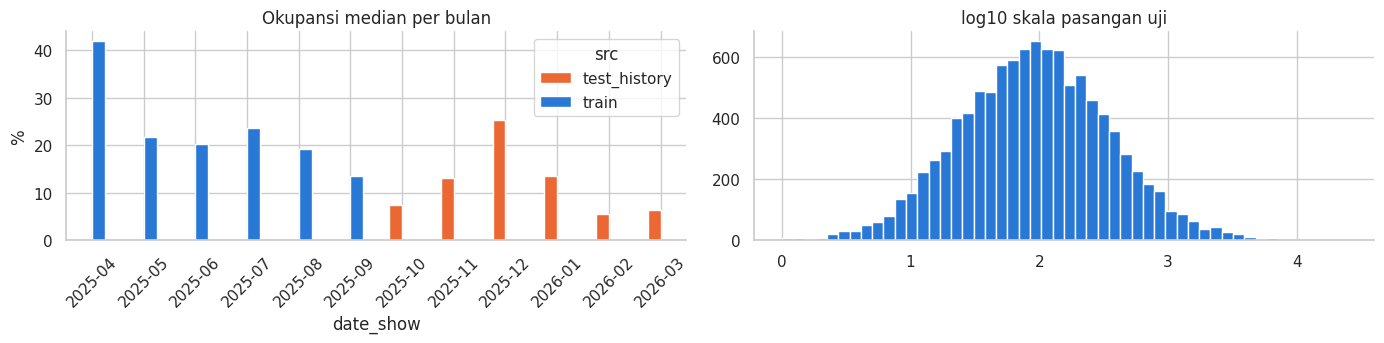

In [10]:
occ = pd.concat([train.assign(src='train'), hist.assign(src='test_history')])
occ_m = occ.groupby([occ.date_show.dt.to_period('M'), 'src']).occupation_rate.median().unstack()
s_te = (hist.groupby(KEY).total_ticket.sum() / 3).clip(lower=1).reindex(pd.MultiIndex.from_frame(test[KEY].drop_duplicates()))
bins = CFG.TW_BINS
print('test pairs by scale bucket:', pd.cut(s_te, bins).value_counts(normalize=True).sort_index().round(3).to_dict())

fig, ax = plt.subplots(1, 2, figsize=(14, 3.6))
occ_m.plot.bar(ax=ax[0], rot=45, color=[PAL[1], PAL[0]]); ax[0].set(title='Okupansi median per bulan', ylabel='%')
ax[1].hist(np.log10(s_te), bins=50, color=PAL[0]); ax[1].set(title='log10 skala pasangan uji')
plt.tight_layout(); plt.savefig(CFG.FIG_DIR / 'market.png'); plt.show()

#### Insights

> Okupansi median Oktober 2025 (7,6%), Februari (5,5%), dan Maret 2026 (6,4%) berada di bawah semua bulan train (13,6% sampai 41,8%). Pasar periode uji jauh lebih sepi, sehingga pasangan uji jauh lebih kecil: 13% baris uji memiliki skala di bawah 20. Konsekuensinya diukur di Bagian 6 dan Bagian 8.

---

# Data Cleaning <a name="5"></a>

---

Target dibentuk dengan zero-fill, sehingga hari ketika sistem pelaporan mati akan menjadi nol palsu. Selain itu, akhir pekan pratinjau berbayar sebelum rilis resmi dapat terbaca sebagai D1.

dates with no data: [datetime.date(2025, 6, 13)]
dates with < 70% of clusters reporting: {Timestamp('2025-06-07 00:00:00'): 10.0, Timestamp('2025-06-09 00:00:00'): 1.0, Timestamp('2025-06-10 00:00:00'): 67.0, Timestamp('2025-06-11 00:00:00'): 76.0, Timestamp('2025-06-16 00:00:00'): 62.0}
A MINECRAFT MOVIE coverage 1-10 Apr: {Timestamp('2025-04-04 00:00:00'): 55, Timestamp('2025-04-05 00:00:00'): 68, Timestamp('2025-04-06 00:00:00'): 67, Timestamp('2025-04-09 00:00:00'): 93, Timestamp('2025-04-10 00:00:00'): 91}


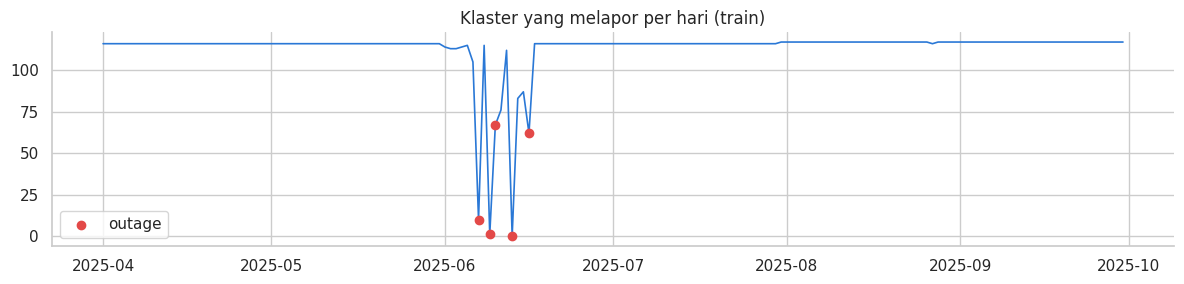

In [11]:
rep = train.groupby('date_show').cinema_ids.nunique().reindex(pd.date_range('2025-04-01', CFG.TRAIN_END))
print('dates with no data:', rep[rep.isna()].index.date.tolist())
print('dates with < 70% of clusters reporting:', rep[rep < 0.7 * rep.median()].to_dict())
mc = train[train.movie_title == 'A MINECRAFT MOVIE'].groupby('date_show').cinema_ids.nunique()
print('A MINECRAFT MOVIE coverage 1-10 Apr:', mc.loc[:'2025-04-10'].to_dict())
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(rep.index, rep.fillna(0), lw=1.2)
ax.scatter(CFG.OUTAGE, rep.reindex(CFG.OUTAGE).fillna(0), color=PAL[7], zorder=3, label='outage')
ax.set(title='Klaster yang melapor per hari (train)'); ax.legend()
plt.tight_layout(); plt.savefig(CFG.FIG_DIR / 'outage.png'); plt.show()

#### Insights

> Lima tanggal Juni 2025 adalah outage pelaporan (13 Juni kosong, 9 Juni hanya 1 klaster). Baris target pada tanggal tersebut dibuang dan film yang D1 sampai D3-nya menyentuh outage tidak dijadikan sampel. A MINECRAFT MOVIE memiliki pratinjau 4 sampai 6 April lalu jeda sebelum rilis resmi 9 April: D1 dicari hanya di dalam segmen tayang kontinu yang memuat puncak cakupan.

---

# Preprocessing <a name="6"></a>

---

`train.csv` tidak memiliki penanda D1 sampai D10. Aturan panitia direplikasi: D1 rilis resmi, rilis luas, pasangan laku di D3, target nol diisi eksplisit. Hasilnya diverifikasi terhadap data uji, termasuk dengan tugas proxy yang memiliki label di dalam periode uji.

## Rekonstruksi D1 dan Simulasi Sampel

D1 adalah hari pertama cakupan klaster judul dasar mencapai 50% puncak, dicari di dalam segmen tayang kontinu yang memuat puncak. Judul dengan cakupan D1 di bawah 25 klaster dipisahkan sebagai film rilis terbatas: tidak pernah dievaluasi, tetapi dipakai sebagai data latih tambahan untuk pasangan kecil.

In [12]:
def release_dates(tx, frac=CFG.D1_FRAC, min_nc=CFG.MIN_NC):
    x = tx.assign(base=base_title(tx.movie_title))
    nc = x.groupby(['base', 'date_show']).cinema_ids.nunique()
    out = {}
    for b, s in nc.groupby(level=0):
        s = s.droplevel(0)
        s = s.reindex(pd.date_range(s.index.min(), s.index.max()), fill_value=0)
        pk = s.idxmax()
        z = s[:pk][s[:pk] == 0]
        seg = s[z.index.max() + pd.Timedelta(days=1):] if len(z) else s
        c = seg[seg >= frac * s.max()]
        if len(c) and c.iloc[0] >= min_nc:
            out[b] = c.index[0]
    t = x.drop_duplicates('movie_title').set_index('movie_title').base
    return t.map(pd.Series(out, dtype='datetime64[ns]')).dropna().rename('d1')


def simulate(tx, d1, last_date=CFG.TRAIN_END, bad=CFG.OUTAGE):
    d1 = d1[d1 + pd.Timedelta(days=9) <= last_date]
    if len(bad):
        d1 = d1[~np.any([(d1 <= b) & (d1 + pd.Timedelta(days=2) >= b) for b in bad], axis=0)]
    x = tx.merge(d1, left_on='movie_title', right_index=True)
    x['d'] = (x.date_show - x.d1).dt.days + 1
    hs = x[x.d.between(1, 3)].drop(columns=['d1', 'd']).reset_index(drop=True)
    pairs = x.loc[x.d == 3, KEY].drop_duplicates().merge(d1, left_on='movie_title', right_index=True)
    tg = pairs.loc[pairs.index.repeat(7)].copy()
    tg['date_show'] = tg.d1 + pd.to_timedelta(np.tile(np.arange(3, 10), len(pairs)), unit='D')
    y = x[x.d.between(4, 10)][KEY + ['date_show', 'total_ticket']]
    tg = tg.merge(y, on=KEY + ['date_show'], how='left').fillna({'total_ticket': 0})
    tg = tg[~tg.date_show.isin(bad)]
    tg['city_name'] = tg.cinema_ids.map(tx.drop_duplicates('cinema_ids').set_index('cinema_ids').city_name)
    return hs, tg.drop(columns='d1').reset_index(drop=True)


def pair_scale(h):
    return (h.groupby(KEY).total_ticket.sum() / 3).clip(lower=1).rename('scale')


def mase(y, p, s):
    return float(np.mean(np.abs(np.asarray(y) - np.asarray(p)) / np.asarray(s)))


first = train.groupby('movie_title').date_show.min()
running = first[first == first.min()].index
D_wide = release_dates(train)
D_lim = release_dates(train, CFG.D1_FRAC, 0).drop(D_wide.index, errors='ignore').drop(running, errors='ignore')
hs, ts = simulate(train, D_wide.drop(running, errors='ignore'))
hl, tl = simulate(train, D_lim)
print(f'wide releases: {ts.movie_title.nunique()} films, {len(ts)} target rows | limited (train only): {tl.movie_title.nunique()} films, {len(tl)} rows')
print('A MINECRAFT MOVIE D1:', D_wide['A MINECRAFT MOVIE'].date())

wide releases: 143 films, 56372 target rows | limited (train only): 36 films, 1435 rows
A MINECRAFT MOVIE D1: 2025-04-09


Fungsi `simulate` diuji pada film sintetis: klaster B tidak laku di D3 sehingga harus dibuang, dan hari tanpa transaksi harus menjadi nol.

In [13]:
dd = pd.date_range('2025-05-01', periods=12)
toy = pd.DataFrame({'date_show': list(dd) + [dd[0], dd[1]], 'cinema_ids': ['A'] * 12 + ['B', 'B'], 'city_name': 'X',
                    'movie_title': 'M', 'total_ticket': list(range(1, 13)) + [5, 5], 'occupation_rate': 1.0,
                    'total_show': 1}).drop(index=5)
th_, tg_ = simulate(toy, pd.Series({'M': dd[0]}, name='d1'), bad=pd.DatetimeIndex([]))
assert set(tg_.cinema_ids) == {'A'} and tg_.total_ticket.tolist() == [4, 5, 0, 7, 8, 9, 10]
assert np.isclose(pair_scale(th_)[('M', 'B')], 10 / 3)
print('simulate() self-check passed')

simulate() self-check passed


## Verifikasi: Komposisi dan Periode Uji

Sampel simulasi dibandingkan dengan data uji. Karena target uji tidak tersedia, dibuat tugas proxy yang memiliki label di **dalam periode uji**: memprediksi D3 dari D1 dan D2. Model proxy dilatih pada train, lalu galatnya per bucket skala dibandingkan antara validasi silang train dan periode uji.

,train_share,test_share,train_cv_mase,test_period_mase,train_zero_D3,test_zero_D3
s,,,,,,
"(0.0, 5.0]",0.004,0.024,1.062,1.171,0.771,0.544
"(5.0, 20.0]",0.053,0.134,0.750,0.693,0.568,0.308
"(20.0, 50.0]",0.134,0.208,0.612,0.587,0.392,0.107
"(50.0, 100.0]",0.173,0.195,0.533,0.481,0.129,0.028
"(100.0, 200.0]",0.217,0.185,0.418,0.410,0.031,0.011
"(200.0, 500.0]",0.249,0.160,0.342,0.344,0.004,0.002
"(500.0, 1000000000.0]",0.170,0.093,0.355,0.285,0.002,0.000


proxy MASE: train CV 0.4544 | re-weighted to test scale mix 0.5232 | real test period 0.4950


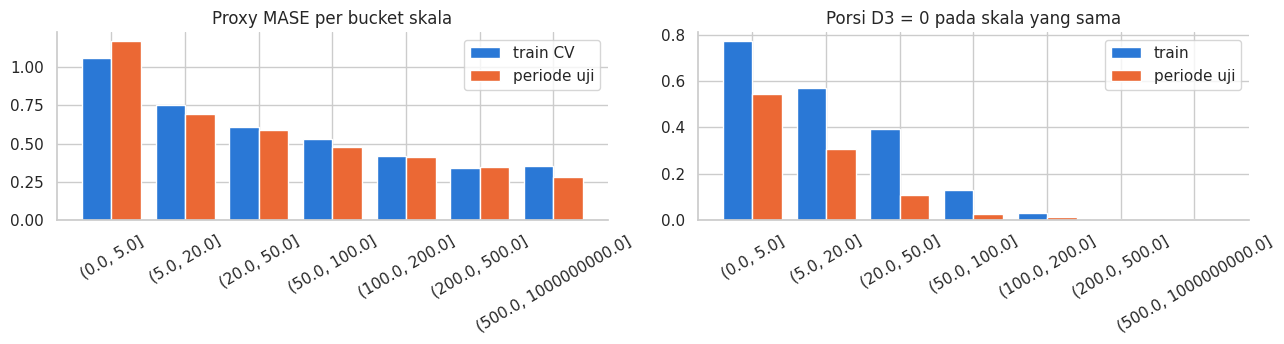

In [14]:
def proxy(hh):
    d1 = hh.groupby('movie_title').date_show.min().rename('d1')
    x = hh.join(d1, on='movie_title')
    x['d'] = (x.date_show - x.d1).dt.days + 1
    P = x.pivot_table(index=KEY, columns='d', values='total_ticket', fill_value=0).reindex(columns=[1, 2, 3], fill_value=0)
    S = x.pivot_table(index=KEY, columns='d', values='total_show', fill_value=0).reindex(columns=[1, 2], fill_value=0)
    O = x.pivot_table(index=KEY, columns='d', values='occupation_rate', fill_value=0).reindex(columns=[1, 2], fill_value=0)
    P = P[P[2] > 0]
    f = pd.DataFrame({'s': ((P[1] + P[2]) / 2).clip(lower=1), 'y': P[3]}, index=P.index)
    f['q1'], f['q2'], f['log_s'] = P[1] / f.s, P[2] / f.s, np.log1p(f.s)
    f['sh1'], f['sh2'] = S.reindex(P.index)[1], S.reindex(P.index)[2]
    f['sh_tr'] = (f.sh2 + 1) / (f.sh1 + 1)
    f['occ2'] = O.reindex(P.index)[2]
    f = f.reset_index().join(d1, on='movie_title')
    g = x[x.d <= 2].groupby(['movie_title', 'd']).total_ticket.sum().unstack().reindex(columns=[1, 2], fill_value=0)
    f['f_tr'] = f.movie_title.map((g[2] + 1) / (g[1] + 1))
    f['f_log'] = f.movie_title.map(np.log1p(g.mean(axis=1)))
    f['f_nc'] = f.movie_title.map(x[x.d == 2].groupby('movie_title').cinema_ids.nunique())
    f['d1_dow'] = f.d1.dt.dayofweek
    return f


PA, PB = proxy(hs), proxy(hist)
pc = ['q1', 'q2', 'log_s', 'sh_tr', 'f_tr', 'f_log', 'd1_dow']
pm = dict(objective='l1', n_estimators=400, learning_rate=0.03, num_leaves=31, min_child_samples=100, verbose=-1, deterministic=True, force_row_wise=True)
oofA = np.zeros(len(PA))
for a, b in GroupKFold(5).split(PA, groups=base_title(PA.movie_title)):
    m = lgb.LGBMRegressor(**pm, random_state=CFG.SEED).fit(PA.iloc[a][pc], PA.y.iloc[a] / PA.s.iloc[a])
    oofA[b] = np.clip(m.predict(PA.iloc[b][pc]), 0, None) * PA.s.values[b]
m = lgb.LGBMRegressor(**pm, random_state=CFG.SEED).fit(PA[pc], PA.y / PA.s)
pB = np.clip(m.predict(PB[pc]), 0, None) * PB.s.values
eA, eB = np.abs(PA.y - oofA) / PA.s, np.abs(PB.y - pB) / PB.s
cutA, cutB = pd.cut(PA.s, bins), pd.cut(PB.s, bins)
tab = pd.DataFrame({'train_share': cutA.value_counts(normalize=True), 'test_share': cutB.value_counts(normalize=True),
                    'train_cv_mase': eA.groupby(cutA, observed=False).mean(), 'test_period_mase': eB.groupby(cutB, observed=False).mean(),
                    'train_zero_D3': (PA.y == 0).groupby(cutA, observed=False).mean(), 'test_zero_D3': (PB.y == 0).groupby(cutB, observed=False).mean()}).sort_index()
display(tab.round(3))
print(f'proxy MASE: train CV {eA.mean():.4f} | re-weighted to test scale mix {(tab.test_share * tab.train_cv_mase).sum():.4f} | real test period {eB.mean():.4f}')

fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
xx = np.arange(len(tab))
ax[0].bar(xx - .2, tab.train_cv_mase, .4, label='train CV'); ax[0].bar(xx + .2, tab.test_period_mase, .4, label='periode uji')
ax[0].set_xticks(xx, [str(i) for i in tab.index], rotation=30); ax[0].set(title='Proxy MASE per bucket skala'); ax[0].legend()
ax[1].bar(xx - .2, tab.train_zero_D3, .4, label='train'); ax[1].bar(xx + .2, tab.test_zero_D3, .4, label='periode uji')
ax[1].set_xticks(xx, [str(i) for i in tab.index], rotation=30); ax[1].set(title='Porsi D3 = 0 pada skala yang sama'); ax[1].legend()
plt.tight_layout(); plt.savefig(CFG.FIG_DIR / 'proxy.png'); plt.show()

#### Insights

> Galat per bucket skala hampir sama antara validasi silang train dan periode uji, tetapi data uji memuat jauh lebih banyak pasangan kecil yang galatnya terbesar. Karena itu metrik keputusan adalah **TW-MASE**. TW-MASE v2 (0,377) dan v3 (0,388) memberi peringkat yang sama dengan leaderboard (0,4506 dan 0,4573), tetapi keduanya berjarak tetap sekitar 0,07.

> Pada skala absolut yang sama, porsi pasangan yang berhenti di D3 jauh lebih kecil di periode uji (skala 20 sampai 50: 0,39 di train vs 0,11 di uji). Bagian berikut menguji apakah ini efek musim atau perubahan perilaku bioskop.

## Kebijakan Pencopotan di Periode Uji

Porsi pasangan yang berhenti laku di D3 dibandingkan pada **permintaan per pertunjukan yang sama** (tiket per show D1 sampai D2), sehingga perbedaan ukuran pasar tidak ikut terhitung. Besarnya pergeseran diestimasi di Bagian 8 setelah kalender tersedia.

,train_drop_D3,test_drop_D3,train_n,test_n
"(0.226, 7.8]",0.499,0.219,948,3070
"(7.8, 14.833]",0.256,0.063,1393,2605
"(14.833, 25.2]",0.085,0.030,1795,2221
"(25.2, 44.9]",0.023,0.014,2296,1702
"(44.9, 425.167]",0.002,0.005,2531,1476


D3 stop rate by release month: {Period('2025-04', 'M'): 0.082, Period('2025-05', 'M'): 0.13, Period('2025-06', 'M'): 0.173, Period('2025-07', 'M'): 0.083, Period('2025-08', 'M'): 0.137, Period('2025-09', 'M'): 0.096, Period('2025-10', 'M'): 0.096, Period('2025-11', 'M'): 0.08, Period('2025-12', 'M'): 0.062, Period('2026-01', 'M'): 0.081, Period('2026-02', 'M'): 0.107, Period('2026-03', 'M'): 0.066}


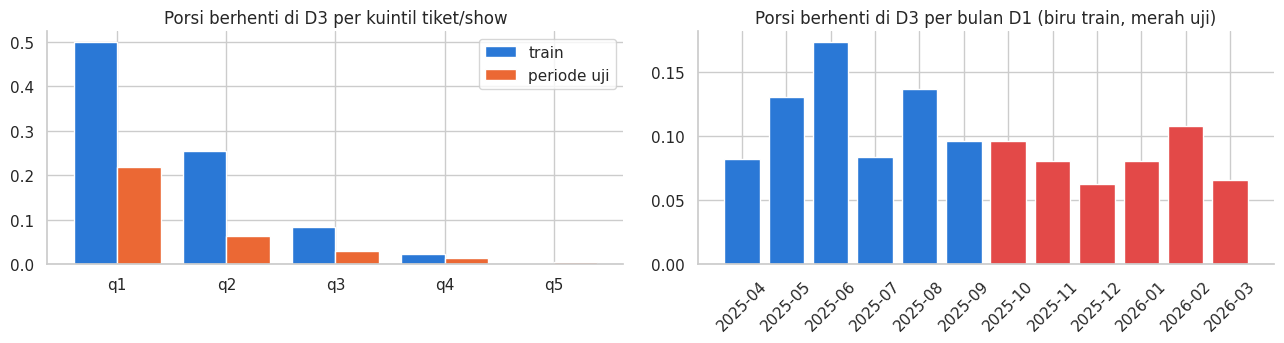

In [15]:
DA = PA.assign(z=PA.y == 0, tps=PA.s * 2 / (PA.sh1 + PA.sh2).clip(lower=1))
DB = PB.assign(z=PB.y == 0, tps=PB.s * 2 / (PB.sh1 + PB.sh2).clip(lower=1))
q = pd.qcut(pd.concat([DA.tps, DB.tps]), 5)
qa, qb = q.iloc[:len(DA)].values, q.iloc[len(DA):].values
tq = pd.DataFrame({'train_drop_D3': DA.z.groupby(qa, observed=False).mean(), 'test_drop_D3': DB.z.groupby(qb, observed=False).mean(),
                   'train_n': pd.Series(qa).value_counts(), 'test_n': pd.Series(qb).value_counts()})
display(tq.round(3))
zm = pd.concat([DA.assign(m=DA.d1.dt.to_period('M')), DB.assign(m=DB.d1.dt.to_period('M'))]).groupby('m').z.mean()
print('D3 stop rate by release month:', zm.round(3).to_dict())

fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
xx = np.arange(len(tq))
ax[0].bar(xx - .2, tq.train_drop_D3, .4, label='train'); ax[0].bar(xx + .2, tq.test_drop_D3, .4, label='periode uji')
ax[0].set_xticks(xx, [f'q{i + 1}' for i in xx]); ax[0].set(title='Porsi berhenti di D3 per kuintil tiket/show'); ax[0].legend()
ax[1].bar(zm.index.astype(str), zm.values, color=[PAL[0] if str(m) < '2025-10' else PAL[7] for m in zm.index])
ax[1].set(title='Porsi berhenti di D3 per bulan D1 (biru train, merah uji)'); ax[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.savefig(CFG.FIG_DIR / 'pull_policy.png'); plt.show()

#### Insights

> Pada tiket per show yang sama, porsi pasangan yang berhenti di D3 di periode uji hanya sekitar setengah sampai seperempat porsi train, di setiap bulan uji, termasuk November dan Desember yang level pasarnya setara bulan-bulan train. Ini bukan efek musim dan bukan data bolong (pola lubang D1 sampai D3 sama), melainkan bioskop di periode uji mempertahankan film pada tingkat penonton yang lebih rendah. Odds pencopotan di D3 sekitar 0,27 kali train, stabil lintas bulan.

> Semua model yang dilatih di train mewarisi kebijakan lama yang lebih cepat mencopot, kandidat kuat penyebab offset leaderboard yang sama di v2 dan v3. Namun di train, kecenderungan mencopot di D3 hampir tidak memprediksi pencopotan D4 sampai D10 (korelasi 0,13 lintas klaster dan bulan), sehingga besarnya pergeseran di horizon target tidak bisa dipastikan. Porsi yang diterapkan dipilih dengan analisis keputusan di Bagian 8.

---

# Feature Engineering <a name="7"></a>

---

Satu fungsi `build` dipanggil identik untuk sampel simulasi dan data uji. Fitur hanya memakai informasi yang tersedia pada D3: riwayat D1 sampai D3, kalender resmi, jadwal rilis film lain yang terlihat di jendela D1 sampai D3 masing-masing, statistik klaster dari masa lalu, dan metadata film.

## Data Eksternal: Kalender Resmi

Hanya sumber yang publik paling lambat 30 September 2025 yang dipakai, seluruhnya fakta kalender pemerintah.

| Sumber | Penerbit | Tanggal terbit | Dipakai untuk |
| :--- | :--- | :--- | :--- |
| [SKB 3 Menteri Libur Nasional dan Cuti Bersama 2025](https://www.kemenkopmk.go.id/skb-3-menteri-libur-nasional-dan-cuti-bersama-tahun-2025) | Kemenko PMK | Oktober 2024 (revisi Agustus 2025) | cuti bersama 2025 |
| [SKB 3 Menteri Libur Nasional dan Cuti Bersama 2026](https://setneg.go.id/baca/index/inilah_skb_3_menteri_libur_nasional_dan_cuti_bersama_2026) | Kemensetneg | 19 September 2025 | cuti bersama 2026; 1 Syawal 1447 H = 21 Maret 2026 |
| [Kalender Pendidikan DKI Jakarta 2024/2025](https://tirto.id/kalender-pendidikan-dki-jakarta-tahun-2024-2025-link-unduh-pdf-g1vR) | Disdik DKI via Tirto | 2024 | libur 28 Juni sampai 12 Juli 2025 |
| [Kalender Pendidikan DKI Jakarta 2025/2026 (Kepdis 89/2025)](https://news.detik.com/berita/d-8049756/kalender-pendidikan-semester-ganjil-2025-2026-jakarta-cek-tanggal-pentingnya) | Disdik DKI via Detik | 7 Agustus 2025 | libur 22 sampai 31 Desember 2025 |

Ramadan 1447 H (19 Februari sampai 20 Maret 2026) diturunkan dari 1 Syawal pada SKB 2026 dikurangi 30 hari.

## Pengali Kalender Struktural

Nilai kalender $c(t)$ = profil hari, dinaikkan ke level akhir pekan pada libur nasional atau cuti bersama di luar Ramadan (cuti bersama akhir Ramadan adalah masa mudik), dan dikali 1,15 pada hari kerja libur sekolah. Pengali target $c_{mult} = c(t) / \overline{c(D1..D3)}$.

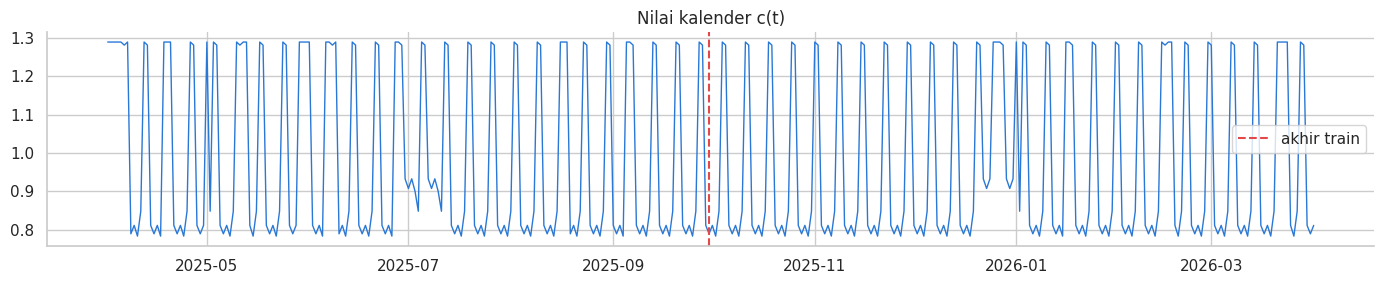

In [16]:
SCHOOL_BREAKS = [('2025-06-28', '2025-07-12'), ('2025-12-22', '2025-12-31')]
CUTI_BERSAMA = pd.to_datetime(['2025-04-02', '2025-04-03', '2025-04-04', '2025-04-07', '2025-05-13', '2025-05-30',
                               '2025-06-09', '2025-08-18', '2025-12-26', '2026-02-16', '2026-03-18', '2026-03-20',
                               '2026-03-23', '2026-03-24'])
RAMADAN = ('2026-02-19', '2026-03-20')


def calendar(hol):
    c = hol.rename(columns={'date': 'date_show'})[['date_show', 'holiday_tipe']].copy()
    c['dow'] = c.date_show.dt.dayofweek
    c['is_hol'] = ((c.holiday_tipe == 'holiday') | c.date_show.isin(CUTI_BERSAMA)).astype(int)
    c['school'] = 0
    for a, b in SCHOOL_BREAKS:
        c.loc[c.date_show.between(a, b), 'school'] = 1
    c['ramadan'] = c.date_show.between(*RAMADAN).astype(int)
    base = CFG.DOW_PROF[c.dow]
    base = np.where((c.school == 1) & (c.dow < 4), base * CFG.SCHOOL_WD, base)
    c['cal'] = np.where((c.is_hol == 1) & (c.ramadan == 0), np.maximum(base, CFG.HOL_LEVEL), base)
    return c.drop(columns='holiday_tipe').set_index('date_show')


CAL = calendar(hol)
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(CAL.index, CAL.cal, lw=1)
ax.axvline(CFG.TRAIN_END, color=PAL[7], ls='--', label='akhir train')
ax.set(title='Nilai kalender c(t)'); ax.legend()
plt.tight_layout(); plt.savefig(CFG.FIG_DIR / 'cal_value.png'); plt.show()

## Fungsi Build Fitur

Kelompok fitur: (1) bentuk kurva pasangan D1 sampai D3, (2) agregat film nasional dan pangsa format, (3) kalender target dan riwayat, (4) jadwal rilis film lain, termasuk film baru yang dibuka di klaster yang sama pada tanggal target (terlihat di jendela D1 sampai D3 film tersebut), (5) ukuran klaster dan harga kota, (6) metadata film, (7) level relatif pasar (median film yang rilis 28 hari sebelumnya, gabungan jendela D1 sampai D3 train dan uji).

In [17]:
GENRES = ['Horror', 'Drama', 'Action', 'Comedy', 'Romance', 'Animation', 'Family', 'Thriller', 'Mystery']
RATING = {'Semua Umur': 0, 'Remaja': 1, 'Dewasa': 2, 'Dewasa 21': 3}


def visible_windows(tx, d1):
    x = tx.merge(d1.rename('d1'), left_on='movie_title', right_index=True)
    return x[(x.date_show >= x.d1) & (x.date_show <= x.d1 + pd.Timedelta(days=2))].drop(columns='d1')


def film_table(vis):
    g = vis.groupby('movie_title')
    return pd.DataFrame({'d1': g.date_show.min(), 'occ': g.occupation_rate.mean(),
                         'tps': g.total_ticket.sum() / g.total_show.sum().clip(lower=1),
                         'logT': np.log1p(g.total_ticket.sum() / 3),
                         'lpc': np.log1p(g.total_ticket.sum() / 3 / g.cinema_ids.nunique().clip(lower=1))})


def make_ctx(visible, size_tx, market):
    rel = visible.assign(base=base_title(visible.movie_title)).groupby('base').agg(
        d1=('date_show', 'min'), tix=('total_ticket', 'sum')).reset_index()
    rel['tix'] /= 3
    cs = size_tx.groupby('cinema_ids').total_ticket.sum() / size_tx.groupby('cinema_ids').date_show.nunique()
    nf = size_tx.groupby(['cinema_ids', 'date_show']).movie_title.nunique().groupby('cinema_ids').mean()
    csh = size_tx.groupby(['cinema_ids', 'date_show']).total_show.sum().groupby('cinema_ids').median()
    return dict(releases=rel, market=market, visible=visible, cin_size=np.log10(cs), cin_nfilms=nf, cin_shows=csh)


def cinema_comp(X, vis, cin_shows):
    v = vis.assign(base=base_title(vis.movie_title))
    agg = v.groupby(['cinema_ids', 'date_show', 'base']).agg(sh=('total_show', 'sum'), tx=('total_ticket', 'sum')).reset_index()
    m = X[['cinema_ids', 'date_show']].assign(base=base_title(X.movie_title)).reset_index().merge(
        agg, on=['cinema_ids', 'date_show'], how='left', suffixes=('', '_o'))
    m = m[m.base != m.base_o]
    g = m.groupby('index').agg(c_new_n=('base_o', 'nunique'), c_new_sh=('sh', 'sum'), c_new_tx=('tx', 'sum'))
    X = X.join(g).fillna({'c_new_n': 0, 'c_new_sh': 0, 'c_new_tx': 0})
    X['c_new_sh_rel'] = X.c_new_sh / X.cinema_ids.map(cin_shows).fillna(X.c_new_sh.median() + 1)
    X['c_new_sh_vs_own'] = X.c_new_sh / X.sh3.clip(lower=1)
    X['c_new_tx_vs_own'] = np.log1p(X.c_new_tx) - np.log1p(X.y3)
    return X


def open_count(X, rel):
    d = np.sort(rel.d1.values.astype('datetime64[D]'))
    a = np.searchsorted(d, X.d1.values.astype('datetime64[D]'), side='right')
    b = np.searchsorted(d, X.date_show.values.astype('datetime64[D]'), side='right')
    return b - a


def build(hh, tgt, ctx):
    mv = movies.set_index('original_title')
    d1 = hh.groupby('movie_title').date_show.min().rename('d1')
    hh = hh.join(d1, on='movie_title')
    hh['d'] = (hh.date_show - hh.d1).dt.days + 1
    piv = lambda v, p: hh.pivot_table(index=KEY, columns='d', values=v, fill_value=0).reindex(columns=[1, 2, 3], fill_value=0).add_prefix(p)
    P = pd.concat([piv('total_ticket', 'y'), piv('total_show', 'sh')], axis=1)
    P['mean3'] = P[['y1', 'y2', 'y3']].mean(axis=1)
    P['scale'] = P.mean3.clip(lower=1)
    P['log_s'] = np.log1p(P.mean3)
    for i in (1, 2, 3):
        P[f'p{i}'] = P[f'y{i}'] / P.scale
    P['n_hist'] = (P[['y1', 'y2', 'y3']] > 0).sum(axis=1)
    P['sh_trend'] = P.sh3 / P[['sh1', 'sh2']].max(axis=1).clip(lower=1)
    P = P.reset_index()

    Fd = hh.groupby(['movie_title', 'd']).agg(T=('total_ticket', 'sum'), nc=('cinema_ids', 'nunique')).unstack().fillna(0)
    Fd.columns = [f'f{a}{b}' for a, b in Fd.columns]
    Fd = Fd.reindex(columns=[f'f{a}{b}' for a in ['T', 'nc'] for b in (1, 2, 3)], fill_value=0)
    Fm = Fd[['fT1', 'fT2', 'fT3']].mean(axis=1).clip(lower=1)
    for i in (1, 2, 3):
        Fd[f'fp{i}'] = Fd[f'fT{i}'] / Fm
    ncmax = Fd[['fnc1', 'fnc2', 'fnc3']].max(axis=1).clip(lower=1)
    Fd['f_logT'] = np.log1p(Fm)
    Fd['f_nc_trend'] = Fd.fnc3 / Fd.fnc1.clip(lower=1)
    Fd['f_occ'] = hh.groupby('movie_title').occupation_rate.mean()
    h3 = hh[hh.d == 3].groupby('movie_title')
    Fd['f_tps3'] = h3.total_ticket.sum() / h3.total_show.sum()
    Fd = Fd.join(d1)
    Fd['base'] = base_title(pd.Series(Fd.index, index=Fd.index))
    Fd['fmt'] = fmt(pd.Series(Fd.index, index=Fd.index)).map({'2D': 0, '3D': 1, 'IMAX 2D': 2, 'IMAX 3D': 3})
    bT = hh.assign(base=base_title(hh.movie_title)).groupby('base').total_ticket.sum() / 3
    Fd['fmt_share'] = np.log1p(Fm) - np.log1p(Fd.base.map(bT))
    Fd['d1_dow'] = Fd.d1.dt.dayofweek
    m = mv.reindex(Fd.base)
    Fd['rating'] = m.age_rating.map(RATING).values
    for g_ in GENRES:
        Fd[f'g_{g_}'] = m.genre.fillna('').str.contains(g_).astype(int).values
    Fd['n_genre'] = m.genre.fillna('').str.count(',').values + 1
    Fd['n_cast'] = m.casts.fillna('').str.count(',').values + 1
    rel = ctx['releases']
    Fd['comp_n'] = [((rel.base != r.base) & (rel.d1 > r.d1) & (rel.d1 <= r.d1 + pd.Timedelta(days=9))).sum() for _, r in Fd.iterrows()]
    Fd['f_share_cohort'] = np.log1p(Fd.base.map(bT)) - np.log1p(Fd.d1.map(rel.groupby('d1').tix.sum()))
    mk = ctx['market']
    win = lambda t: mk[(mk.d1 < t) & (mk.d1 >= t - pd.Timedelta(days=28))]
    Fd[['mk_occ', 'mk_tps', 'mk_logT', 'mk_lpc']] = [win(t)[['occ', 'tps', 'logT', 'lpc']].median().tolist() for t in Fd.d1]
    Fd['occ_rel'] = Fd.f_occ / Fd.mk_occ
    Fd['tps_rel'] = Fd.f_tps3 / Fd.mk_tps
    Fd['logT_rel'] = Fd.f_logT - Fd.mk_logT
    Fd['film_pc_vs_mkt'] = np.log1p(Fm / ncmax) - Fd.mk_lpc

    X = tgt.merge(P, on=KEY, how='left').merge(Fd.drop(columns=['base']), left_on='movie_title', right_index=True, how='left')
    X['h'] = (X.date_show - X.d1).dt.days + 1
    cT = CAL.reindex(X.date_show)
    X['dow'] = cT.dow.values
    X['t_hol'], X['t_school'], X['t_ramadan'] = cT.is_hol.values, cT.school.values, cT.ramadan.values
    ch = np.stack([CAL.cal.reindex(X.d1 + pd.Timedelta(days=k)).values for k in range(3)], 1)
    X['cal_mult'] = cT.cal.values / ch.mean(1)
    X['hol_in_hist'] = np.stack([CAL.is_hol.reindex(X.d1 + pd.Timedelta(days=k)).values for k in range(3)], 1).sum(1)
    X['n_comp_open'] = open_count(X, rel)
    X = cinema_comp(X, ctx['visible'], ctx['cin_shows'])
    X['share'] = X.log_s - np.log1p(X[['fT1', 'fT2', 'fT3']].mean(axis=1) / X.fnc3.clip(lower=1))
    X['pair_vs_mkt'] = X.log_s - X.mk_lpc
    X['p3_rel'] = X.p3 - X.fp3
    X['p1_rel'] = X.p1 - X.fp1
    X['cin_size'] = X.cinema_ids.map(ctx['cin_size'])
    X['cin_nfilms'] = X.cinema_ids.map(ctx['cin_nfilms'])
    X['cin_new'] = X.cin_size.isna().astype(int)
    pr = price.pivot(index='city_name', columns='price_day', values='ceil')
    X['price_wkd'] = X.city_name.map(pr.Weekday)
    X['price_prem'] = X.city_name.map(pr.Weekend / pr.Weekday)
    return X

Fitur dibangun untuk film rilis luas, film rilis terbatas (hanya latih), dan data uji. Tiga pemeriksaan wajib: jumlah baris tetap, urutan `id` uji tetap, dan skala sama persis dengan fungsi `hitung_skala` resmi.

In [18]:
vis_tr = visible_windows(train, D_wide)
market = pd.concat([film_table(vis_tr), film_table(hist)])
ctx_tr = make_ctx(vis_tr, train, market)
Xtr = build(hs, ts, ctx_tr)
Xlim = build(hl, tl, ctx_tr)
Xte = build(hist, test, make_ctx(hist, train, market))

assert len(Xtr) == len(ts) and len(Xte) == len(test) and (Xte.id.values == test.id.values).all()
ref = Xte.join(pair_scale(hist), on=KEY, rsuffix='_ref')
assert np.allclose(ref.scale, ref.scale_ref)

BASE_FEATS = ['log_s', 'p1', 'p2', 'p3', 'n_hist', 'sh_trend', 'fnc1', 'fnc2', 'fnc3', 'fp1', 'fp2', 'fp3', 'f_logT',
              'f_nc_trend', 'fmt', 'fmt_share', 'd1_dow', 'rating'] + [f'g_{g_}' for g_ in GENRES] + [
              'n_genre', 'n_cast', 'comp_n', 'f_share_cohort', 'h', 'dow', 't_hol', 't_school', 't_ramadan', 'cal_mult',
              'hol_in_hist', 'n_comp_open', 'share', 'p3_rel', 'p1_rel', 'cin_size', 'cin_nfilms', 'cin_new',
              'price_wkd', 'price_prem']
FEATS = BASE_FEATS
ZFEATS = FEATS + ['c_new_n', 'c_new_sh', 'c_new_sh_rel', 'c_new_sh_vs_own', 'c_new_tx_vs_own']
print(f'train {len(Xtr)} rows | limited extra {len(Xlim)} | test {len(Xte)} | features {len(FEATS)}')
display(pd.DataFrame({'train_median': Xtr[['log_s', 'f_logT', 'pair_vs_mkt', 'film_pc_vs_mkt', 'share']].median(),
                      'test_median': Xte[['log_s', 'f_logT', 'pair_vs_mkt', 'film_pc_vs_mkt', 'share']].median()}).round(3))

train 56372 rows | limited extra 1435 | test 72611 | features 47


,train_median,test_median
log_s,5.204,4.529
f_logT,9.974,9.450
pair_vs_mkt,0.019,-0.123
film_pc_vs_mkt,0.353,0.286
share,-0.379,-0.435


## Verifikasi Drift: Adversarial Validation

Classifier dilatih membedakan baris simulasi dari baris uji dengan fold dikelompokkan per film (split acak memberi AUC palsu 1,0 karena fitur level film konstan dalam satu film).

In [19]:
def adv_auc(cols):
    A = pd.concat([Xtr[cols].assign(t=0, g=Xtr.movie_title), Xte[cols].assign(t=1, g=Xte.movie_title)], ignore_index=True)
    oof = np.zeros(len(A))
    for a, b in StratifiedGroupKFold(5, shuffle=True, random_state=CFG.SEED).split(A, A.t, A.g):
        m = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05, random_state=CFG.SEED, verbose=-1)
        oof[b] = m.fit(A.iloc[a][cols], A.t.iloc[a]).predict_proba(A.iloc[b][cols])[:, 1]
    return roc_auc_score(A.t, oof)


shape_cols = ['p1', 'p2', 'p3', 'fp1', 'fp3', 'share', 'sh_trend', 'd1_dow', 'n_hist']
print(f"AUC shape features only:         {adv_auc(shape_cols):.3f}")
print(f"AUC + absolute level (log_s, f_logT): {adv_auc(shape_cols + ['log_s', 'f_logT']):.3f}")
print(f"AUC + market-relative level:     {adv_auc(shape_cols + ['pair_vs_mkt', 'film_pc_vs_mkt']):.3f}")

AUC shape features only:         0.510
AUC + absolute level (log_s, f_logT): 0.544
AUC + market-relative level:     0.479


#### Insights

> Fitur bentuk kurva tidak bisa membedakan train dan uji (AUC sekitar 0,51). Level absolut menaikkan AUC (sekitar 0,54) karena pasar uji lebih sepi, sedangkan level relatif pasar tidak menaikkannya (sekitar 0,48): median `log_s` bergeser 0,67 tetapi `pair_vs_mkt` hanya 0,14. Varian `both` memanfaatkan hal ini.

---

# Modeling <a name="8"></a>

---

Semua model memakai fold yang sama (5 fold per judul dasar) dan dinilai dengan MASE biasa serta TW-MASE: setiap baris dibobot agar bucket skalanya memiliki porsi yang sama dengan data uji.

In [20]:
groups = base_title(Xtr.movie_title).values
ug = np.array(sorted(set(groups)))
fold_of = dict(zip(ug, np.random.RandomState(CFG.SEED).permutation(len(ug)) % CFG.N_FOLDS))
FOLD = np.array([fold_of[g_] for g_ in groups])
y, s, cm, hh_ = Xtr.total_ticket.values, Xtr.scale.values, Xtr.cal_mult.values, Xtr.h.values

bt = pd.cut(Xtr.scale, CFG.TW_BINS)
tw = bt.map(pd.cut(Xte.scale, CFG.TW_BINS).value_counts(normalize=True) / bt.value_counts(normalize=True)).astype(float).values
TW = tw / tw.mean()


def score(p, name, yy=None):
    yy = y if yy is None else yy
    e = np.abs(yy - p) / s
    r = dict(model=name, MASE=e.mean(), TW_MASE=np.average(e, weights=TW), small=e[s <= 20].mean(), big=e[s > 200].mean())
    print(f"{name:40s} MASE {r['MASE']:.4f} | TW-MASE {r['TW_MASE']:.4f} | s<=20 {r['small']:.4f} | s>200 {r['big']:.4f}")
    return r


def train_part(k):
    Xa = Xtr[FOLD != k]
    return pd.concat([Xa, Xlim], ignore_index=True) if CFG.USE_LIMITED else Xa


results = []
rc = y / s / cm
oof_base = np.zeros(len(Xtr))
for k in range(CFG.N_FOLDS):
    a, b = FOLD != k, FOLD == k
    med = pd.Series(rc[a]).groupby([hh_[a], Xtr.d1_dow.values[a]]).median()
    oof_base[b] = med.reindex(pd.MultiIndex.from_arrays([hh_[b], Xtr.d1_dow.values[b]])).fillna(np.median(rc[a])).values * cm[b] * s[b]
results.append(score(np.zeros(len(Xtr)), 'zero'))
results.append(score(oof_base, 'median r/c by (h, D1 dow)'))

zero                                     MASE 0.5881 | TW-MASE 0.6104 | s<=20 0.8820 | s>200 0.6309
median r/c by (h, D1 dow)                MASE 0.4002 | TW-MASE 0.4951 | s<=20 0.9822 | s>200 0.3279


## Estimasi Pergeseran Kebijakan Pencopotan

Klasifier $P(y_3 = 0)$ dilatih pada proxy train (D1 dan D2 -> D3), diterapkan ke proxy periode uji, lalu intersep koreksi $a$ pada skala logit diestimasi dari label periode uji: $\text{logit}\,p_{uji} = \text{logit}\,p_{train} + a$. Konfigurasi sama dengan analisis lokal (`eda/21` dan `eda/25`) agar $a$ konsisten dengan pemilihan $\lambda$.

In [21]:
for Pp in (PA, PB):
    c3 = np.stack([CAL.cal.reindex(Pp.d1 + pd.Timedelta(days=k)).values for k in range(3)], 1)
    Pp['cm'] = c3[:, 2] / c3[:, :2].mean(1)
PCOLS = ['q1', 'q2', 'log_s', 'sh1', 'sh2', 'sh_tr', 'occ2', 'f_tr', 'f_log', 'f_nc', 'cm', 'd1_dow']
clf = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31, min_child_samples=100, verbose=-1,
                         deterministic=True, force_row_wise=True, random_state=CFG.SEED).fit(PA[PCOLS], PA.y == 0)
logit = lambda p: np.log(p / (1 - p))
sigm = lambda t: 1 / (1 + np.exp(-t))
pB0 = np.clip(clf.predict_proba(PB[PCOLS])[:, 1], 1e-4, 1 - 1e-4)
zB = (PB.y == 0).values
grid = np.linspace(-4, 2, 601)
nll = lambda p, z, a: -np.mean(z * np.log(sigm(logit(p) + a)) + (1 - z) * np.log(1 - sigm(logit(p) + a)))
PULL_A = float(grid[np.argmin([nll(pB0, zB, a) for a in grid])])
mon = PB.d1.dt.to_period('M').astype(str).values
per_month = {m: round(float(grid[np.argmin([nll(pB0[mon == m], zB[mon == m], a) for a in grid])]), 2) for m in sorted(set(mon))}
print(f'pull-odds shift a = {PULL_A:.3f} (odds x {np.exp(PULL_A):.2f}); mean p0 train-model {pB0.mean():.3f} -> '
      f'shifted {sigm(logit(pB0) + PULL_A).mean():.3f} | observed {zB.mean():.3f}')
print('per test month:', per_month)

pull-odds shift a = -1.320 (odds x 0.27); mean p0 train-model 0.146 -> shifted 0.085 | observed 0.085
per test month: {'2025-10': -1.1, '2025-11': 0.0, '2025-12': -1.87, '2026-01': -1.26, '2026-02': -1.68, '2026-03': -1.87}


## LightGBM: L1 dan Hurdle

Model L1 langsung menaksir median $r$. Model hurdle memisahkan dua keputusan: klasifier $p_0 = P(r = 0)$ dan 19 regresi kuantil ($\tau = 0{,}05, \dots, 0{,}95$) untuk $r \mid r > 0$. Klasifier memakai tambahan fitur kompetisi per klaster (AUC lokal 0,927 menjadi 0,930; TW-MASE hurdle 0,387 menjadi 0,384), yang pada model L1 dan kuantil tidak membantu. Hyperparameter dipilih dengan TW-MASE dunia $\kappa = 0{,}5$ (`eda/30`): klasifier 31 daun (0,4038 vs 0,4058 dengan 63 daun), kuantil 63 daun dan 19 level (39 level hanya 0,0002 lebih baik). Median campuran dihitung dengan rumus di bagian Approach; pergeseran kebijakan pencopotan diterapkan dengan menggeser logit $p_0$.

In [22]:
LGB_BASE = {k: v for k, v in CFG.LGB_PARAMS.items() if k not in ('objective', 'n_estimators')}
LGB_FAST = {**LGB_BASE, 'n_estimators': 300, 'learning_rate': 0.05}


def r_target(Xa):
    return (Xa.total_ticket / Xa.scale / Xa.cal_mult).values


def fit_lgb_all(Xa):
    l1 = [lgb.LGBMRegressor(objective='l1', n_estimators=CFG.LGB_PARAMS['n_estimators'], **LGB_BASE, random_state=sd)
          .fit(Xa[FEATS], r_target(Xa), sample_weight=Xa.cal_mult.values) for sd in CFG.SEEDS]
    zc = lgb.LGBMClassifier(objective='binary', **{**LGB_FAST, 'num_leaves': 31}, random_state=CFG.SEED).fit(Xa[ZFEATS], Xa.total_ticket == 0)
    pos = Xa[Xa.total_ticket > 0]
    qm = [lgb.LGBMRegressor(objective='quantile', alpha=float(q), **LGB_FAST, random_state=CFG.SEED).fit(pos[FEATS], r_target(pos))
          for q in CFG.QS]
    return dict(l1=l1, zc=zc, qm=qm)


def predict_lgb_all(m, Xb):
    l1 = np.clip(np.mean([mm.predict(Xb[FEATS]) for mm in m['l1']], 0), 0, None)
    p0 = m['zc'].predict_proba(Xb[ZFEATS])[:, 1]
    Q = np.sort(np.column_stack([mm.predict(Xb[FEATS]) for mm in m['qm']]), axis=1)
    return l1, p0, Q


def mixture_median(p0, Q, qs, lam):
    p = sigm(logit(np.clip(p0, 1e-4, 1 - 1e-4)) + lam * PULL_A)
    t = np.clip((0.5 - p) / (1 - p), qs[0], qs[-1])
    val = np.array([np.interp(ti, qs, qi) for ti, qi in zip(t, Q)])
    return np.where(p >= 0.5, 0.0, np.clip(val, 0, None))


t0 = time.time()
oof_l1, oof_p0, oof_Q = np.zeros(len(Xtr)), np.zeros(len(Xtr)), np.zeros((len(Xtr), len(CFG.QS)))
for k in range(CFG.N_FOLDS):
    v = FOLD == k
    oof_l1[v], oof_p0[v], oof_Q[v] = predict_lgb_all(fit_lgb_all(train_part(k)), Xtr[v])
    print(f'fold {k} done ({time.time() - t0:.0f}s)')
results.append(score(oof_l1 * cm * s, 'LightGBM L1'))
results.append(score(mixture_median(oof_p0, oof_Q, CFG.QS, 0.0) * cm * s, 'LightGBM hurdle (lambda 0)'))

fold 0 done (81s)
fold 1 done (166s)
fold 2 done (247s)
fold 3 done (328s)
fold 4 done (411s)
LightGBM L1                              MASE 0.3244 | TW-MASE 0.4073 | s<=20 0.8672 | s>200 0.2693
LightGBM hurdle (lambda 0)               MASE 0.3094 | TW-MASE 0.3841 | s<=20 0.8010 | s>200 0.2621


## Analisis Keputusan: Bobot Hurdle dan Porsi Pergeseran

Besarnya pergeseran kebijakan pencopotan di D4 sampai D10 tidak bisa diamati. Dua skenario dievaluasi pada baris out-of-fold: **dunia nyata** (target seperti adanya, pergeseran tidak berlaku di horizon target) dan **dunia bergeser** (setiap target nol dibatalkan dengan peluang $1 - p_0'/p_0$, $\text{logit}\,p_0' = \text{logit}\,p_0 + \kappa a$ dengan $\kappa = 0{,}5$, lalu diganti sampel dari distribusi positif out-of-fold-nya). Nilai $\kappa = 0{,}5$ membuat TW-MASE v3, v4, dan v5 sejalan dengan leaderboard masing-masing (offset v5 hanya 0,002), sehingga dunia ini adalah metrik keputusan. Sumber bukti ketiga adalah proxy D3 periode uji (script EDA lokal `eda/25`): blend 50 persen hurdle dengan $\lambda = 1$ memberi 0,4680 vs L1 0,4734, sedangkan hurdle murni kalah dari L1 di 10 dari 10 split. Pasangan (bobot, $\lambda$) dipilih dengan **minimax regret** atas ketiga sumber tersebut. Konsistensi dengan versi sebelumnya: selisih leaderboard v3 ke v4 (0,0092) sama dengan selisih TW-MASE keduanya di dunia dengan separuh pergeseran D3 (0,011), sehingga $\lambda = 0{,}5$ dipertahankan.

zero rate: real 0.300 | shifted world 0.245


,lam,w,real,shifted,regret_real,regret_shifted,max_regret
9,0.5,1.00,0.3885,0.4017,0.0043,0.0000,0.0043
4,0.0,1.00,0.3841,0.4073,0.0000,0.0056,0.0056
8,0.5,0.75,0.3909,0.4045,0.0068,0.0028,0.0068
3,0.0,0.75,0.3879,0.4090,0.0038,0.0073,0.0073
2,0.0,0.50,0.3931,0.4122,0.0090,0.0105,0.0105
7,0.5,0.50,0.3948,0.4090,0.0107,0.0073,0.0107
13,1.0,0.75,0.3994,0.4055,0.0153,0.0038,0.0153
1,0.0,0.25,0.3995,0.4169,0.0154,0.0152,0.0154


chosen in Settings: HURDLE_W=0.75, LAMBDA=0.5
LightGBM mix (hurdle w, lambda)          MASE 0.3135 | TW-MASE 0.3909 | s<=20 0.8203 | s>200 0.2631


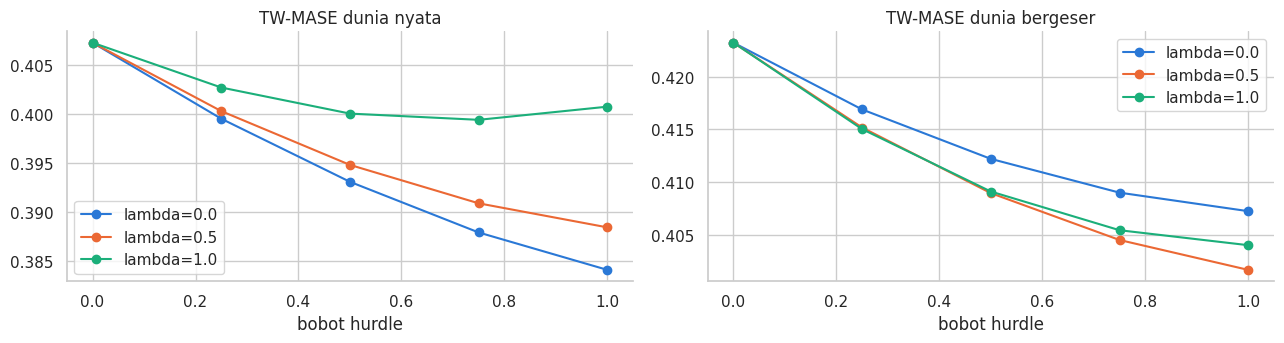

In [23]:
rng = np.random.default_rng(CFG.SEED)
p_sh = sigm(logit(np.clip(oof_p0, 1e-4, 1 - 1e-4)) + CFG.KAPPA * PULL_A)
unpull = (y == 0) & (rng.random(len(y)) < 1 - p_sh / np.clip(oof_p0, 1e-6, None))
draw = np.array([np.interp(u, CFG.QS, q) for u, q in zip(rng.random(len(y)), oof_Q)])
y_shift = np.where(unpull, np.clip(draw, 0, None) * cm * s, y)
print(f'zero rate: real {np.mean(y == 0):.3f} | shifted world {np.mean(y_shift == 0):.3f}')

twm = lambda yy, pr: np.average(np.abs(yy - pr) / s, weights=TW)
rows = []
for lam in (0.0, 0.5, 1.0):
    hu = mixture_median(oof_p0, oof_Q, CFG.QS, lam)
    for w in (0.0, 0.25, 0.5, 0.75, 1.0):
        pr = ((1 - w) * oof_l1 + w * hu) * cm * s
        rows.append(dict(lam=lam, w=w, real=twm(y, pr), shifted=twm(y_shift, pr)))
D = pd.DataFrame(rows)
for c in ('real', 'shifted'):
    D[f'regret_{c}'] = D[c] - D[c].min()
D['max_regret'] = D[['regret_real', 'regret_shifted']].max(axis=1)
display(D.round(4).sort_values('max_regret').head(8))
print(f'chosen in Settings: HURDLE_W={CFG.HURDLE_W}, LAMBDA={CFG.LAMBDA}')
oof_lgbmix = ((1 - CFG.HURDLE_W) * oof_l1 + CFG.HURDLE_W * mixture_median(oof_p0, oof_Q, CFG.QS, CFG.LAMBDA)) * cm * s
results.append(score(oof_lgbmix, 'LightGBM mix (hurdle w, lambda)'))

fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
for lam, g in D.groupby('lam'):
    ax[0].plot(g.w, g.real, marker='o', label=f'lambda={lam}')
    ax[1].plot(g.w, g.shifted, marker='o', label=f'lambda={lam}')
ax[0].set(title='TW-MASE dunia nyata', xlabel='bobot hurdle'); ax[1].set(title='TW-MASE dunia bergeser', xlabel='bobot hurdle')
ax[0].legend(); ax[1].legend()
plt.tight_layout(); plt.savefig(CFG.FIG_DIR / 'decision.png'); plt.show()

#### Insights

> Hurdle murni adalah yang terbaik di dunia nyata (kira-kira 0,021 lebih baik dari L1 pada TW-MASE lokal), tetapi di proxy periode uji justru kalah dari L1: hurdle lebih akurat pada pasangan yang tetap laku, sedangkan L1 lebih tahan pada pasangan yang ternyata dicopot. Blend keduanya menang di kedua validasi. Minimax regret atas dunia nyata, dunia bergeser, dan proxy periode uji memilih bobot hurdle 0,75 dengan $\lambda = 0{,}5$ (regret maksimum sekitar 0,008, dibanding sekitar 0,018 untuk hurdle murni tanpa koreksi).

## Pretrained Model: TabPFN-3.5 per Horizon (Kuantil)

TabPFN-3.5 ([Prior-Labs/tabpfn_3_5](https://huggingface.co/Prior-Labs/tabpfn_3_5), Prior Labs, rilis 9 September 2026) adalah tabular foundation model yang dilatih pada data sintetis dan memprediksi lewat in-context learning dengan distribusi prediktif penuh. Bobot `tabpfn-v3.5-20260909.safetensors` diunduh dengan revisi terkunci `06bf2ba3` memakai token Hugging Face dari Kaggle Secrets (`HF_TOKEN`) dan dipanggil lewat `TabPFNRegressor.create_default_for_version(ModelVersion.V3_5)` dari paket `tabpfn==9.0.0`. Model ini dipakai sebagai pretrained model publik yang diperbolehkan; batas publikasi 30 September 2025 pada aturan lomba berlaku untuk data eksternal. Pembanding yang pernah diuji: TabPFN v2 (TW-MASE 0,3876, dipakai v3 sampai v5), TabDPT 1.1.5 (gagal dengan `faiss` terbaru), dan LimiX-16M (butuh flash-attention yang tidak mendukung T4).

Dari 49 kuantil prediktif dibaca $p_0$ (porsi kuantil di bawah `ZERO_EPS`) dan fungsi kuantil campuran, sehingga koreksi pencopotan yang sama ($\lambda a$) dapat diterapkan tanpa model tambahan.

In [24]:
TAB_FEATS = [c for c in FEATS if c != 'h']


def hf_token():
    if os.environ.get('HF_TOKEN'):
        return os.environ['HF_TOKEN']
    if UserSecretsClient is not None:
        try:
            return UserSecretsClient().get_secret('HF_TOKEN')
        except Exception:
            return None
    return None


def tabpfn_path():
    local = list(Path('/kaggle/input').rglob(CFG.TABPFN_FILE)) if CFG._ON_KAGGLE else []
    if local:
        return str(local[0])
    # local_dir keeps the real file name: tabpfn picks the loader from the .safetensors suffix
    return hf_hub_download(CFG.TABPFN_REPO, CFG.TABPFN_FILE, revision=CFG.TABPFN_REV, token=hf_token(),
                           local_dir=str(CFG.OUTPUT_DIR / 'tabpfn'))


def tabpfn_quantiles(Xa, Xb):
    out = np.zeros((len(Xb), len(CFG.TAB_QS)))
    for hz in range(4, 11):
        ia, ib = (Xa.h == hz).values, (Xb.h == hz).values
        if ib.sum() == 0:
            continue
        m = TabPFNRegressor.create_default_for_version(ModelVersion.V3_5, model_path=TABPFN_CKPT, device=CFG.DEVICE,
                                                        n_estimators=CFG.TABPFN_EST, random_state=CFG.SEED,
                                                        ignore_pretraining_limits=True)
        m.fit(Xa[ia][TAB_FEATS].values.astype(np.float32), r_target(Xa)[ia])
        Qb = Xb[ib][TAB_FEATS].values.astype(np.float32)
        out[ib] = np.concatenate([np.asarray(m.predict(Qb[i:i + 3000], output_type='quantiles', quantiles=list(CFG.TAB_QS))).T
                                  for i in range(0, len(Qb), 3000)])
    return np.sort(out, axis=1)


def tabpfn_median(Q, lam):
    p0 = np.array([np.interp(CFG.ZERO_EPS, q, CFG.TAB_QS, left=0.0, right=1.0) for q in Q])
    p = sigm(logit(np.clip(p0, 1e-4, 1 - 1e-4)) + lam * PULL_A)
    u = np.clip(p0 + (1 - p0) * (0.5 - p) / (1 - p), CFG.TAB_QS[0], CFG.TAB_QS[-1])
    val = np.array([np.interp(ui, CFG.TAB_QS, qi) for ui, qi in zip(u, Q)])
    return np.where(p >= 0.5, 0.0, np.clip(val, 0, None))


oof_tabQ = None
if CFG.USE_TABPFN:
    TABPFN_CKPT = tabpfn_path()
    t0 = time.time()
    oof_tabQ = np.zeros((len(Xtr), len(CFG.TAB_QS)))
    for k in range(CFG.N_FOLDS):
        oof_tabQ[FOLD == k] = tabpfn_quantiles(train_part(k), Xtr[FOLD == k])
        print(f'fold {k} done ({time.time() - t0:.0f}s)')
    results.append(score(tabpfn_median(oof_tabQ, 0.0) * cm * s, 'TabPFN-3.5 median (lambda 0)'))
    results.append(score(tabpfn_median(oof_tabQ, CFG.LAMBDA) * cm * s, 'TabPFN-3.5 median (lambda)'))

tabpfn-v3.5-20260909.safetensors:   0%|          | 0.00/876M [00:00<?, ?B/s]

fold 0 done (98s)
fold 1 done (203s)
fold 2 done (311s)
fold 3 done (418s)
fold 4 done (526s)
TabPFN-3.5 median (lambda 0)             MASE 0.3070 | TW-MASE 0.3815 | s<=20 0.7953 | s>200 0.2597
TabPFN-3.5 median (lambda)               MASE 0.3091 | TW-MASE 0.3840 | s<=20 0.8027 | s>200 0.2612


## TabPFN-3.5 Fine-Tuned: Satu Model untuk Semua Horizon

Model in-context di atas hanya melihat sekitar 8 ribu baris per horizon. Paket `tabpfn==9.0.0` menyediakan `FinetunedTabPFNRegressor`, yang memperbarui bobot TabPFN-3.5 pada data kita: setiap langkah mengambil konteks dan query dari 56 ribu baris latih (horizon sebagai fitur), dengan loss **CRPS** atas distribusi prediktif (proper scoring rule untuk distribusi penuh, sehingga median-nya tetap cocok untuk MASE) dan learning rate kecil (1e-5) dengan early stopping. Fine-tuning diulang per fold agar prediksi out-of-fold jujur, dengan batas waktu per fold. Bila gagal (misalnya kehabisan memori GPU), komponen ini dilewati tanpa menghentikan notebook.

In [25]:
def ft_model():
    return FinetunedTabPFNRegressor(device=CFG.DEVICE, epochs=CFG.FT_EPOCHS, time_limit=CFG.FT_TIME, learning_rate=CFG.FT_LR,
                                    validation_split_ratio=0.1, n_finetune_ctx_plus_query_samples=CFG.FT_CTX,
                                    finetune_ctx_query_split_ratio=0.2, n_inference_subsample_samples=CFG.FT_INF_CTX,
                                    random_state=CFG.SEED, n_estimators_finetune=2, n_estimators_validation=2,
                                    n_estimators_final_inference=CFG.TABPFN_EST, mse_loss_weight=0.0, crps_loss_weight=1.0,
                                    model_version=ModelVersion.V3_5, extra_regressor_kwargs={'model_path': TABPFN_CKPT})


def ft_quantiles(Xa, Xb):
    m = ft_model()
    m.fit(Xa[FEATS].values.astype(np.float32), r_target(Xa).astype(np.float32))
    Qb = Xb[FEATS].values.astype(np.float32)
    out = np.concatenate([np.asarray(m.predict(Qb[i:i + 3000], output_type='quantiles', quantiles=list(CFG.TAB_QS))).T
                          for i in range(0, len(Qb), 3000)])
    return np.sort(out, axis=1)


oof_ftQ = None
if CFG.USE_TABPFN and CFG.USE_FT:
    t0 = time.time()
    try:
        oof_ftQ = np.zeros((len(Xtr), len(CFG.TAB_QS)))
        for k in range(CFG.N_FOLDS):
            oof_ftQ[FOLD == k] = ft_quantiles(train_part(k), Xtr[FOLD == k])
            print(f'fine-tune fold {k} done ({time.time() - t0:.0f}s)')
            torch.cuda.empty_cache()
        results.append(score(tabpfn_median(oof_ftQ, 0.0) * cm * s, 'TabPFN-3.5 fine-tuned (lambda 0)'))
        results.append(score(tabpfn_median(oof_ftQ, CFG.LAMBDA) * cm * s, 'TabPFN-3.5 fine-tuned (lambda)'))
    except Exception as e:
        print('fine-tuning skipped:', type(e).__name__, str(e)[:300])
        oof_ftQ = None
        torch.cuda.empty_cache()

Finetuning Epoch 1/30:   0%|          | 0/4 [00:00<?, ?it/s]

Finetuning Epoch 2/30:   0%|          | 0/4 [00:00<?, ?it/s]

Finetuning Epoch 3/30:   0%|          | 0/4 [00:00<?, ?it/s]

Finetuning Epoch 4/30:   0%|          | 0/4 [00:00<?, ?it/s]

Finetuning Epoch 5/30:   0%|          | 0/4 [00:00<?, ?it/s]

...

Finetuning Epoch 4/30:   0%|          | 0/5 [00:00<?, ?it/s]

Finetuning Epoch 5/30:   0%|          | 0/5 [00:00<?, ?it/s]

Finetuning Epoch 6/30:   0%|          | 0/5 [00:00<?, ?it/s]

Finetuning Epoch 7/30:   0%|          | 0/5 [00:00<?, ?it/s]

fine-tune fold 4 done (4143s)
TabPFN-3.5 fine-tuned (lambda 0)         MASE 0.3147 | TW-MASE 0.3895 | s<=20 0.8036 | s>200 0.2668
TabPFN-3.5 fine-tuned (lambda)           MASE 0.3180 | TW-MASE 0.3968 | s<=20 0.8284 | s>200 0.2656


## Blending Tiga Komponen

Komponen LightGBM (L1 + hurdle), TabPFN-3.5 in-context per horizon, dan TabPFN-3.5 fine-tuned, semuanya dengan $\lambda$ yang sama, di-blend linear. Bobot dicari pada grid simpleks berjarak 0,1 memakai TW-MASE di dunia $\kappa = 0{,}5$. Blend distribusi tidak lagi dibandingkan karena kalah tipis dari blend median pada v6 (0,4023 vs 0,4009 di run Kaggle) maupun eksperimen lokal (0,4039 vs 0,4025).

In [26]:
COMP = {'lgb': oof_lgbmix}
if oof_tabQ is not None:
    COMP['tabpfn'] = tabpfn_median(oof_tabQ, CFG.LAMBDA) * cm * s
if oof_ftQ is not None:
    COMP['tabpfn_ft'] = tabpfn_median(oof_ftQ, CFG.LAMBDA) * cm * s
names = list(COMP)
grid = np.round(np.arange(0, 1.01, 0.1), 1)
cands = [w for w in itertools.product(grid, repeat=len(names)) if abs(sum(w) - 1) < 1e-9]
rows = []
for w in cands:
    pr = sum(wi * COMP[n] for wi, n in zip(w, names))
    rows.append(dict(zip([f'w_{n}' for n in names], w), real=twm(y, pr), kappa=twm(y_shift, pr)))
BW = pd.DataFrame(rows).sort_values('kappa')
display(BW.head(8).round(4))
WEIGHTS = {n: float(BW.iloc[0][f'w_{n}']) for n in names}
oof_final = sum(WEIGHTS[n] * COMP[n] for n in names)
print('chosen weights:', WEIGHTS)
err = pd.DataFrame({n: (y - COMP[n]) / s for n in names})
print('signed-error correlation:\n', err.corr().round(3))
results.append(score(oof_final, 'final blend'))
results.append(score(oof_final, 'final blend, kappa=0.5 world', yy=y_shift))
display(pd.DataFrame(results).set_index('model').round(4))

,w_lgb,w_tabpfn,w_tabpfn_ft,real,kappa
50,0.5,0.5,0.0,0.3846,0.4009
44,0.4,0.6,0.0,0.3840,0.4010
55,0.6,0.4,0.0,0.3854,0.4010
37,0.3,0.7,0.0,0.3837,0.4014
49,0.5,0.4,0.1,0.3856,0.4014
43,0.4,0.5,0.1,0.3850,0.4015
59,0.7,0.3,0.0,0.3865,0.4015
54,0.6,0.3,0.1,0.3865,0.4017


chosen weights: {'lgb': 0.5, 'tabpfn': 0.5, 'tabpfn_ft': 0.0}
signed-error correlation:
              lgb  tabpfn  tabpfn_ft
lgb        1.000   0.988      0.989
tabpfn     0.988   1.000      0.994
tabpfn_ft  0.989   0.994      1.000
final blend                              MASE 0.3085 | TW-MASE 0.3846 | s<=20 0.8082 | s>200 0.2595
final blend, kappa=0.5 world             MASE 0.3124 | TW-MASE 0.4009 | s<=20 0.8859 | s>200 0.2530


,MASE,TW_MASE,small,big
model,,,,
zero,0.5881,0.6104,0.8820,0.6309
"median r/c by (h, D1 dow)",0.4002,0.4951,0.9822,0.3279
LightGBM L1,0.3244,0.4073,0.8672,0.2693
LightGBM hurdle (lambda 0),0.3094,0.3841,0.8010,0.2621
"LightGBM mix (hurdle w, lambda)",0.3135,0.3909,0.8203,0.2631
TabPFN-3.5 median (lambda 0),0.3070,0.3815,0.7953,0.2597
TabPFN-3.5 median (lambda),0.3091,0.3840,0.8027,0.2612
TabPFN-3.5 fine-tuned (lambda 0),0.3147,0.3895,0.8036,0.2668
TabPFN-3.5 fine-tuned (lambda),0.3180,0.3968,0.8284,0.2656


#### Insights

> Pada eksperimen lokal (`eda/31` dan `eda/32`, TabPFN-3.5 dengan 4 anggota ensemble di CPU), TabPFN-3.5 mengalahkan TabPFN v2 dengan jelas: TW-MASE dunia nyata 0,3826 vs 0,3876 dan TW-MASE dunia $\kappa = 0{,}5$ 0,4052 vs 0,4136. $P(y = 0)$ yang tersirat dari kuantilnya terkalibrasi (0,298 vs porsi nol aktual 0,300).

> Blend median LightGBM dan TabPFN-3.5 (bobot sekitar 0,5) memberi TW-MASE dunia $\kappa = 0{,}5$ 0,4009 di run Kaggle v6 dan leaderboard 0,4012. Model tabular foundation lain yang diuji lokal, TabICL v2 (`eda/35` dan `eda/36`), jauh lebih buruk (0,4564) karena distribusi prediktifnya tidak menaruh massa di nol (P(nol) tersirat 0,21 vs aktual 0,30) dan mendapat bobot nol, sehingga tidak dipakai.

---

# Evaluation <a name="9"></a>

---

Galat out-of-fold model final dibedah per bucket skala (dengan porsi uji), per horizon, dan per film, lalu kontribusi setiap bucket terhadap MASE uji yang diharapkan dihitung.

,test_share,train_share,mase,zero_rate,contribution_to_test
scale,,,,,
"(0.0, 5.0]",0.015,0.003,2.557,0.758,0.039
"(5.0, 20.0]",0.114,0.029,0.637,0.761,0.073
"(20.0, 50.0]",0.198,0.101,0.405,0.622,0.080
"(50.0, 100.0]",0.200,0.169,0.316,0.520,0.063
"(100.0, 200.0]",0.195,0.235,0.291,0.333,0.057
"(200.0, 500.0]",0.178,0.276,0.277,0.151,0.049
"(500.0, 1000000000.0]",0.100,0.188,0.234,0.026,0.023


MASE by horizon: {4: 0.336, 5: 0.363, 6: 0.291, 7: 0.294, 8: 0.281, 9: 0.286, 10: 0.307}
worst films: {'SORE ISTRI DARI MASA DEPAN': 2.11, 'UNTIL DAWN': 1.43, 'SAYAP SAYAP PATAH 2: OLIVIA': 1.2, 'LILO & STITCH': 1.03, 'MATERIALISTS': 0.72}


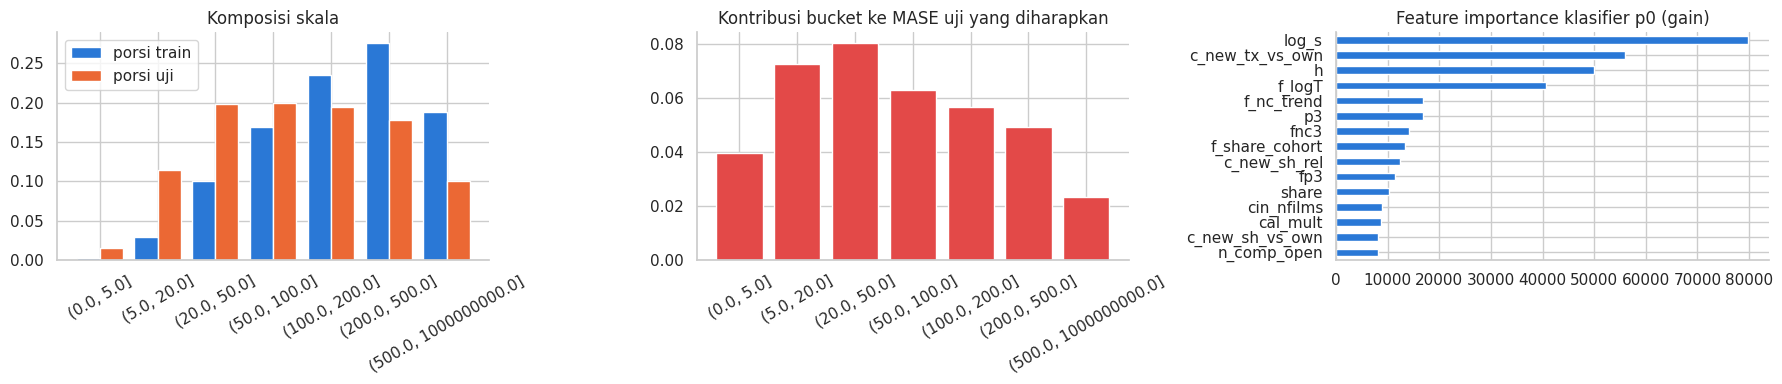

In [27]:
E = Xtr[['movie_title', 'h', 'scale', 'total_ticket']].assign(pred=oof_final)
E['ae'] = np.abs(E.total_ticket - E.pred) / E.scale
cut = pd.cut(E.scale, CFG.TW_BINS)
bk = pd.DataFrame({'test_share': pd.cut(Xte.scale, CFG.TW_BINS).value_counts(normalize=True), 'train_share': cut.value_counts(normalize=True),
                   'mase': E.groupby(cut, observed=False).ae.mean(), 'zero_rate': (E.total_ticket == 0).groupby(cut, observed=False).mean()}).sort_index()
bk['contribution_to_test'] = bk.test_share * bk.mase
display(bk.round(3))
print('MASE by horizon:', E.groupby('h').ae.mean().round(3).to_dict())
print('worst films:', E.groupby('movie_title').ae.mean().nlargest(5).round(2).to_dict())

imp = pd.Series(fit_lgb_all(pd.concat([Xtr, Xlim], ignore_index=True))['zc'].booster_.feature_importance('gain'), index=ZFEATS)
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
xx = np.arange(len(bk))
ax[0].bar(xx - .2, bk.train_share, .4, label='porsi train'); ax[0].bar(xx + .2, bk.test_share, .4, label='porsi uji')
ax[0].set_xticks(xx, [str(i) for i in bk.index], rotation=30); ax[0].legend(); ax[0].set_title('Komposisi skala')
ax[1].bar(xx, bk.contribution_to_test, color=PAL[7]); ax[1].set_xticks(xx, [str(i) for i in bk.index], rotation=30)
ax[1].set_title('Kontribusi bucket ke MASE uji yang diharapkan')
imp.nlargest(15)[::-1].plot.barh(ax=ax[2], color=PAL[0]); ax[2].set_title('Feature importance klasifier p0 (gain)')
plt.tight_layout(); plt.savefig(CFG.FIG_DIR / 'evaluation.png'); plt.show()

#### Insights

> Pasangan dengan skala di bawah 50 hanya sekitar 13% baris train tetapi 33% baris uji dan menyumbang porsi terbesar MASE uji yang diharapkan. Klasifier $p_0$ paling bergantung pada bentuk kurva D1 sampai D3 dan posisi kalender (horizon, hari), yaitu kapan pergantian program terjadi.

---

# Inference & Submission <a name="10"></a>

---

Model final dilatih pada seluruh sampel (rilis luas dan rilis terbatas) dengan konfigurasi yang dipilih di Bagian 8. Tidak ada parameter yang disetel pada leaderboard: $a$ berasal dari data berlabel periode uji, bobot hurdle, $\lambda$, dan bobot TabPFN dari validasi out-of-fold, dan level minggu Lebaran dari total klaster Lebaran 2025 di data latih.

## Minggu Lebaran: Analog Top-Down dari Lebaran 2025

Tujuh judul slate Lebaran 2026 dirilis 18 Maret, sehingga D4 sampai D10 mereka adalah Lebaran hari 1 sampai 7 (6,1% baris uji), periode yang tidak memiliki padanan di sampel latih. Namun `train.csv` dimulai 1 April 2025, yaitu Lebaran 2025 hari ke-2, sehingga total tiket per klaster selama minggu Lebaran 2025 teramati. Prediksi top-down: total slate per klaster pada Lebaran hari ke-$k$ = $\rho$ x total klaster pada Lebaran 2025 hari ke-$k$, dibagi ke pasangan menurut pangsa skala D1 sampai D3. Rasio klaster dirata-rata geometrik dengan rasio nasional agar tidak liar pada klaster kecil.

slate: ['DANUR: THE LAST CHAPTER', 'DANUR: THE LAST CHAPTER (IMAX 2D)', 'NA WILLA', 'PELANGI DI MARS', 'SENIN HARGA NAIK', 'SUZZANNA: SANTET DOSA DI ATAS DOSA', 'TUNGGU AKU SUKSES NANTI']
normal 2025 day 217072 | 2025 Lebaran week mean 593714 | 2026 slate mean D1-D3 167461
2026 slate: 1003361 seats/day at occupancy 17% | 2025 slate occupancy median 73%


,rho=0.4,rho=0.5,rho=0.7,rho=1.0,occupancy_needed_rho=0.5
D4 (Lebaran day 1),0.83,1.03,1.45,2.07,17.0
D5 (Lebaran day 2),1.10,1.38,1.93,2.76,23.0
D6 (Lebaran day 3),1.34,1.68,2.35,3.35,28.0
D7 (Lebaran day 4),1.51,1.89,2.64,3.77,31.0
D8 (Lebaran day 5),1.49,1.86,2.61,3.72,31.0
D9 (Lebaran day 6),1.58,1.98,2.77,3.96,33.0
D10 (Lebaran day 7),1.48,1.85,2.59,3.71,31.0


analog mean r by Lebaran day: {1: 1.09, 2: 1.45, 3: 1.78, 4: 2.01, 5: 1.98, 6: 2.1, 7: 1.98}


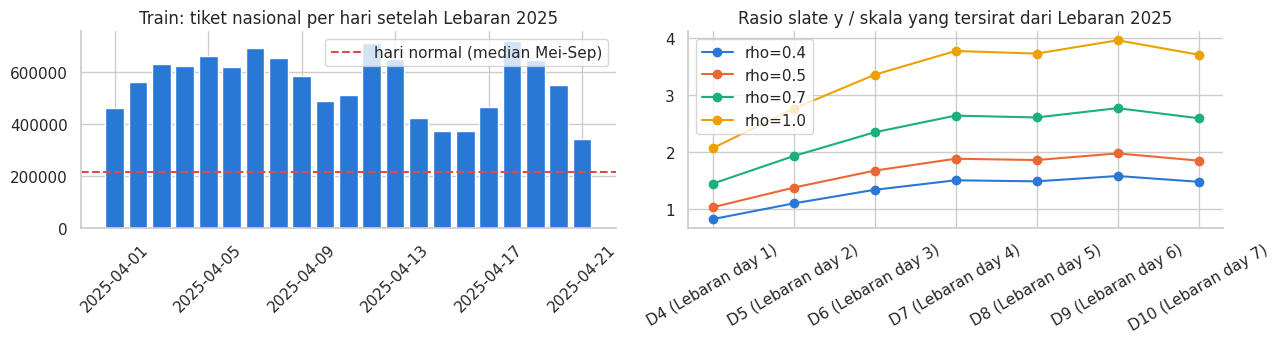

In [28]:
LEB25, LEB26 = pd.Timestamp('2025-03-31'), pd.Timestamp('2026-03-21')
leb_mask = Xte.date_show.between(LEB26, LEB26 + pd.Timedelta(days=6)).values
slate = sorted(Xte.movie_title[leb_mask].unique())
hsl = hist[hist.movie_title.isin(slate)]
day25 = train.groupby('date_show').total_ticket.sum()
normal_day = day25.loc['2025-05-01':].median()
m25 = pd.Series({k: day25[LEB25 + pd.Timedelta(days=k - 1)] for k in range(2, 8)})
m25.loc[1] = CFG.LEB_DAY1 * m25.loc[2]
m25 = m25.sort_index()
S26 = hsl.groupby('date_show').total_ticket.sum().mean()
seats26 = (hsl.total_ticket / (hsl.occupation_rate / 100).clip(lower=.005)).groupby(hsl.date_show).sum().mean()
top25 = train[train.date_show.between('2025-04-01', '2025-04-07')].groupby('movie_title').total_ticket.sum().nlargest(5).index
a25 = train[train.movie_title.isin(top25) & train.date_show.between('2025-04-01', '2025-04-07')]
print('slate:', slate)
print(f'normal 2025 day {normal_day:.0f} | 2025 Lebaran week mean {m25.loc[2:7].mean():.0f} | 2026 slate mean D1-D3 {S26:.0f}')
print(f'2026 slate: {seats26:.0f} seats/day at occupancy {100 * S26 / seats26:.0f}% | 2025 slate occupancy median {a25.occupation_rate.median():.0f}%')
imp_r = pd.DataFrame({f'rho={r_}': r_ * m25 / S26 for r_ in (0.4, 0.5, 0.7, 1.0)})
imp_r.index = [f'D{k + 3} (Lebaran day {k})' for k in imp_r.index]
imp_r['occupancy_needed_rho=0.5'] = (0.5 * m25.values / seats26 * 100).round(0)
display(imp_r.round(2))

c25 = {k: train[train.date_show == LEB25 + pd.Timedelta(days=k - 1)].groupby('cinema_ids').total_ticket.sum() for k in range(2, 8)}
c25[1] = CFG.LEB_DAY1 * c25[2]
c26 = hsl.groupby('cinema_ids').total_ticket.sum() / 3
kday = (Xte.date_show - LEB26).dt.days.values + 1
leb_pred = np.zeros(len(Xte))
for k in range(1, 8):
    m = leb_mask & (kday == k)
    r_nat = m25.loc[k] / S26
    r_cl = (Xte.cinema_ids[m].map(c25[k]) / Xte.cinema_ids[m].map(c26)).values
    r_cl = np.where(np.isfinite(r_cl) & (r_cl > 0), r_cl, r_nat)
    # geometric mean of cluster and national ratio
    leb_pred[m] = Xte.scale.values[m] * CFG.LEB_RHO * np.sqrt(r_cl * r_nat)
print('analog mean r by Lebaran day:', {int(k): round(float((leb_pred / Xte.scale.values)[leb_mask & (kday == k)].mean()), 2) for k in range(1, 8)})

dd = day25.loc['2025-04-01':'2025-04-21']
fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
ax[0].bar(dd.index, dd.values, color=PAL[0]); ax[0].axhline(normal_day, color=PAL[7], ls='--', label='hari normal (median Mei-Sep)')
ax[0].set(title='Train: tiket nasional per hari setelah Lebaran 2025'); ax[0].legend(); ax[0].tick_params(axis='x', rotation=45)
imp_r[['rho=0.4', 'rho=0.5', 'rho=0.7', 'rho=1.0']].plot(ax=ax[1], marker='o'); ax[1].tick_params(axis='x', rotation=30)
ax[1].set(title='Rasio slate y / skala yang tersirat dari Lebaran 2025')
plt.tight_layout(); plt.savefig(CFG.FIG_DIR / 'lebaran.png'); plt.show()

#### Insights

> Minggu Lebaran 2025 berjalan di sekitar 608 ribu tiket per hari pada klaster yang sama (2,8 kali hari normal) dan tetap 2,3 sampai 3 kali normal pada hari kerja setelah cuti bersama. Slate 2026 sudah menawarkan sekitar satu juta kursi per hari pada D1 sampai D3 dengan okupansi hanya 15 sampai 23%, sedangkan slate Lebaran 2025 mencapai okupansi median 73%. Model statistik memprediksi slate turun ke sekitar 129 ribu tiket per hari (rasio 0,79, anjlok ke 0,25 pada 25 sampai 27 Maret), setara okupansi 13% pada minggu puncak tahunan, yang tidak masuk akal secara fisik.

> Analog memakai $\rho = 0{,}5$: slate diasumsikan hanya mencapai separuh total pasar Lebaran 2025 (rasio rata-rata sekitar 1,7, okupansi tersirat di bawah 35%). Bahkan skenario pesimis (pasar 60% dari 2025 dan pangsa slate 70%) memberi rasio 1,4. Nilai ini ditetapkan dari data 2025 dan kapasitas kursi, bukan dari leaderboard. Sumber eksternal pendukung yang terbit sebelum batas: pemberitaan April 2025 tentang 2 juta penonton dalam 3 hari libur Lebaran dan 5 juta penonton selama libur Lebaran.

In [29]:
t0 = time.time()
Xall = pd.concat([Xtr, Xlim], ignore_index=True) if CFG.USE_LIMITED else Xtr
final_lgb = fit_lgb_all(Xall)
te_l1, te_p0, te_Q = predict_lgb_all(final_lgb, Xte)
cm_te, s_te_ = Xte.cal_mult.values, Xte.scale.values
te_comp = {'lgb': ((1 - CFG.HURDLE_W) * te_l1 + CFG.HURDLE_W * mixture_median(te_p0, te_Q, CFG.QS, CFG.LAMBDA)) * cm_te * s_te_}
if WEIGHTS.get('tabpfn', 0) > 0:
    te_comp['tabpfn'] = tabpfn_median(tabpfn_quantiles(Xall, Xte), CFG.LAMBDA) * cm_te * s_te_
if WEIGHTS.get('tabpfn_ft', 0) > 0:
    try:
        te_comp['tabpfn_ft'] = tabpfn_median(ft_quantiles(Xall, Xte), CFG.LAMBDA) * cm_te * s_te_
    except Exception as e:  # e.g. GPU OOM on the larger final context: renormalise over the other components
        print('final fine-tune failed, dropped from blend:', repr(e)[:200]); torch.cuda.empty_cache()
pred = sum(WEIGHTS[n] * te_comp[n] for n in te_comp) / sum(WEIGHTS[n] for n in te_comp)
pred = np.clip(pred, 0, None)
print('model mean r on Lebaran rows:', round(float((pred / s_te_)[leb_mask].mean()), 3), '-> analog', round(float((leb_pred / s_te_)[leb_mask].mean()), 3))
pred = np.where(leb_mask, leb_pred, pred)
print(f'final fit + inference: {time.time() - t0:.0f}s')

seg = pd.Series('normal', index=Xte.index)
for n, (a, b) in SEGMENTS.items():
    seg[Xte.date_show.between(a, b)] = n
rr = pred / s_te_
display(pd.DataFrame({'rows': seg.value_counts(), 'mean_r_hat': pd.Series(rr).groupby(seg.values).mean(),
                      'pred_zero_share': pd.Series(rr < .05).groupby(seg.values).mean()}).round(3))

model mean r on Lebaran rows: 0.787 -> analog 1.769
final fit + inference: 622s


,rows,mean_r_hat,pred_zero_share
lebaran,4417,1.769,0.000
normal,50551,0.481,0.282
ramadan,12408,0.378,0.419
xmas,5235,0.638,0.062


Submisi disimpan dengan format `id,total_ticket` dan urutan `id` yang sama dengan `sample_submission.csv`. Bobot model (booster LightGBM L1, klasifier, dan kuantil) serta konfigurasi disimpan sebagai satu berkas `.pkl`; bobot TabPFN adalah checkpoint publik yang diunduh dengan revisi terkunci.

In [30]:
submission = pd.DataFrame({'id': test.id.values, 'total_ticket': pred})
assert len(submission) == len(sub) and (submission.id.values == sub.id.values).all()
assert submission.total_ticket.notna().all() and (submission.total_ticket >= 0).all()
submission.to_csv(CFG.OUTPUT_DIR / 'submission.csv', index=False)
pd.DataFrame({'movie_title': Xtr.movie_title, 'cinema_ids': Xtr.cinema_ids, 'h': Xtr.h, 'fold': FOLD, 'y': y, 'scale': s,
              'oof_l1': oof_l1 * cm * s, 'oof_lgbmix': oof_lgbmix, 'oof_final': oof_final}).to_csv(CFG.OUTPUT_DIR / 'oof.csv', index=False)
with open(CFG.OUTPUT_DIR / 'model_weights.pkl', 'wb') as f:
    pickle.dump({'l1': [m.booster_.model_to_string() for m in final_lgb['l1']],
                 'zero_clf': final_lgb['zc'].booster_.model_to_string(),
                 'quantiles': [m.booster_.model_to_string() for m in final_lgb['qm']], 'features': FEATS,
                 'pull_a': PULL_A, 'blend_weights': WEIGHTS, 'tabpfn_revision': CFG.TABPFN_REV,
                 'settings': {k: v for k, v in vars(Settings).items() if k.isupper()}}, f)
print(f"weights: {(CFG.OUTPUT_DIR / 'model_weights.pkl').stat().st_size / 1e6:.1f} MB")
display(submission.head())

weights: 62.9 MB


,id,total_ticket
0,1,31.331781
1,2,26.012820
2,3,9.649858
3,4,0.029084
4,5,0.106517


#### Insights

> v5 mempertahankan metrik keputusan TW-MASE, model hurdle, dan koreksi kebijakan pencopotan yang diukur dari data berlabel periode uji. Dua tambahan v5 juga tidak memakai leaderboard: fitur kompetisi per klaster dipilih dengan validasi out-of-fold, dan level minggu Lebaran diturunkan dari total klaster Lebaran 2025 dengan faktor konservatif.

> Seluruh proses deterministik: seed tetap pada numpy, torch, LightGBM (`deterministic=True`), TabPFN (`random_state`), fold, dan simulasi dunia bergeser; revisi bobot TabPFN dikunci ke commit Hugging Face.